#MAPEO DE SERIES DE TIEMPO DE ANOMALÍAS DE ENOS Y CAUDAL

##DEFINICIONES

In [1]:
import numpy as np
import networkx as nx
import itertools
import matplotlib.pyplot as plt


# ============================================================
# Mapeo global de permutaciones (predefinido para w=4)
# ============================================================

# Generar todas las permutaciones posibles de (1,2,3,4)
w_fijo = 4
permutaciones = list(itertools.permutations(range(1, w_fijo+1)))
permutaciones.sort()  # Orden lexicográfico para consistencia

# Crear mapeos globales
MAQUINA_ESTADOS = {perm: idx for idx, perm in enumerate(permutaciones)}  # perm -> índice 0-23
INDICE_A_PERM = {idx: perm for idx, perm in enumerate(permutaciones)}  # índice -> perm
NUM_NODOS_GLOBAL = len(permutaciones)  # 24

# ============================================================
# 1. Crear nodos (ordinal patterns) - MODIFICADA
# ============================================================

def crear_ind(x, tamaño_w):
    """
    Devuelve la lista de patrones ordinales mapeados a índices globales.
    Usa el mapeo MAQUINA_ESTADOS para garantizar consistencia.
    """
    x = np.asarray(x)
    N = len(x)
    w = int(tamaño_w)
    if N < w:
        return []

    ind_x1 = []
    for i in range(0, N - w + 1):
        sub = x[i:i+w]

        # Orden de índices de mayor a menor (Small 2013 define orden por "pi_j-th largest")
        order_desc = np.argsort(sub, kind='stable')[::-1]  # índices del mayor al menor

        # Construir ranking: ranks[pos] = 1..w (1 = mayor)
        ranks = np.empty(w, dtype=int)
        ranks[order_desc] = np.arange(1, w+1)

        pat = tuple(ranks.tolist())
        # Mapear a índice global usando MAQUINA_ESTADOS
        idx = MAQUINA_ESTADOS[pat]
        ind_x1.append(idx)

    return ind_x1

# ============================================================
# 2. Crear grafo (ahora PESADO) - MODIFICADA
# ============================================================

def crear_grafo(ind_x1, tamaño_w):
    """
    Construye un grafo NO dirigido y PESADO con 24 nodos fijos.
    La matriz de adyacencia siempre es de 24×24.
    """
    # Crear grafo con todos los nodos posibles (0-23)
    G = nx.Graph()
    for i in range(NUM_NODOS_GLOBAL):
        G.add_node(i)

    # Inicializar diccionario de etiquetas
    nodo_a_sublista = INDICE_A_PERM.copy()  # copia del mapeo global

    # Añadir aristas incrementando peso (transiciones cada w pasos)
    w = int(tamaño_w)
    for i in range(len(ind_x1) - w):
        a = ind_x1[i]  # ya es índice global
        b = ind_x1[i + w]  # ya es índice global
        if G.has_edge(a, b):
            G[a][b]['weight'] += 1
        else:
            G.add_edge(a, b, weight=1)

    # unique_nodes es el mapeo inverso para compatibilidad
    unique_nodes = {perm: idx for idx, perm in INDICE_A_PERM.items()}

    return G, unique_nodes, nodo_a_sublista

# ============================================================
# 3. Calcular entropía usando matriz de conectividad PESADA - MODIFICADA
# ============================================================

def calcular_entropia(unique_nodes, ind_x1, w):
    """
    Calcula entropía con matriz de adyacencia de 24×24.
    """
    # Inicializar matriz 24×24 (no usa unique_nodes para el tamaño)
    matriz_conectividad = np.zeros((NUM_NODOS_GLOBAL, NUM_NODOS_GLOBAL), dtype=int)

    w_int = int(w)
    # Rellenar matriz con conteos de transiciones
    for i in range(len(ind_x1) - w_int):
        a = ind_x1[i]  # índice global
        b = ind_x1[i + w_int]  # índice global
        matriz_conectividad[a, b] += 1
        matriz_conectividad[b, a] += 1  # red no dirigida

    # sumas por fila = fuerza (grado ponderado)
    sum_m = matriz_conectividad.sum(axis=1)

    mu = []
    for i in range(NUM_NODOS_GLOBAL):
        if sum_m[i] == 0:
            mu.append(0.0)
            continue
        ent = 0.0
        for j in range(NUM_NODOS_GLOBAL):
            if matriz_conectividad[i, j] > 0:
                p = matriz_conectividad[i, j] / sum_m[i]
                ent -= p * np.log2(p)
        mu.append(ent)

    mut = float(np.mean(mu)) if NUM_NODOS_GLOBAL > 0 else 0.0

    return mu, mut, matriz_conectividad




In [2]:
import numpy as np
import networkx as nx
import itertools
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. Extraer patrones ordinales (para cualquier w)
# ------------------------------------------------------------
def obtener_patrones(x, w):
    """
    Devuelve una lista de tuplas, cada una es el patrón ordinal (permutación)
    de una ventana deslizante de longitud w sobre la serie x.
    El orden es de mayor a menor, con desempate estable (primero aparece = más pequeño).
    """
    x = np.asarray(x)
    N = len(x)
    if N < w:
        return []
    patrones = []
    for i in range(N - w + 1):
        sub = x[i:i+w]
        # Índices ordenados de mayor a menor (argsort descendente estable)
        order_desc = np.argsort(sub, kind='stable')[::-1]
        # Asignar rangos: 1 al más grande, w al más pequeño
        ranks = np.empty(w, dtype=int)
        ranks[order_desc] = np.arange(1, w+1)
        patrones.append(tuple(ranks))
    return patrones

# ------------------------------------------------------------
# 2. Construir grafo a partir de la lista de patrones
# ------------------------------------------------------------
def construir_grafo(patrones, w):
    """
    Construye un grafo no dirigido y pesado.
    - Nodos: patrones ordinales distintos que aparecen en la serie.
    - Aristas: entre patrones que ocurren en tiempos sucesivos no solapados
               (separados por w pasos). El peso acumula el número de transiciones.
    """
    # Mapear cada patrón único a un índice local
    unique_pat = {}
    for p in patrones:
        if p not in unique_pat:
            unique_pat[p] = len(unique_pat)
    num_nodes = len(unique_pat)

    # Crear grafo con todos los nodos (inicialmente aislados)
    G = nx.Graph()
    G.add_nodes_from(range(num_nodes))

    # Añadir aristas con peso (transiciones cada w pasos, sin solapamiento)
    for i in range(len(patrones) - w):
        a = unique_pat[patrones[i]]
        b = unique_pat[patrones[i + w]]
        if G.has_edge(a, b):
            G[a][b]['weight'] += 1
        else:
            G.add_edge(a, b, weight=1)

    # También devolvemos el mapeo inverso (índice -> patrón) por si se necesita
    idx_to_pat = {v: k for k, v in unique_pat.items()}
    return G, idx_to_pat

# ------------------------------------------------------------
# 3. Calcular entropía de la red (promedio de entropías nodales)
# ------------------------------------------------------------
def calcular_entropia_red(G):
    """
    Calcula la entropía nodal promedio para un grafo pesado no dirigido.
    Para cada nodo i: μ(i) = - Σ_j p(i,j) log2 p(i,j), con p(i,j) = peso(i,j) / fuerza(i).
    La entropía total es el promedio sobre todos los nodos.
    Los nodos aislados contribuyen con 0.
    """
    entropias = []
    for node in G.nodes():
        # Obtener pesos de las aristas incidentes
        weights = [G[node][nbr]['weight'] for nbr in G.neighbors(node)]
        strength = sum(weights)
        if strength == 0:
            entropias.append(0.0)
            continue
        # Calcular entropía
        ent = 0.0
        for wgt in weights:
            p = wgt / strength
            ent -= p * np.log2(p)
        entropias.append(ent)
    return np.mean(entropias) if entropias else 0.0

# ------------------------------------------------------------
# 4. Función de optimización de w (adaptada)
# ------------------------------------------------------------
def optimizar_w(x, w_min, w_max):
    """
    Encuentra el valor óptimo de w que maximiza la entropía promedio de la red.

    Parámetros:
        x (list): Serie temporal.
        w_min (int): Valor mínimo de w (inclusive).
        w_max (int): Valor máximo de w (exclusive, como en range).

    Retorna:
        w_optimo (int): w que maximiza la entropía.
    """
    valores_w = range(w_min, w_max)
    entropias = []

    for w in valores_w:
        # 1. Obtener patrones ordinales
        patrones = obtener_patrones(x, w)
        if len(patrones) < w + 1:   # se necesitan al menos dos transiciones
            entropias.append(0.0)
            continue

        # 2. Construir grafo
        G, _ = construir_grafo(patrones, w)

        # 3. Calcular entropía promedio
        ent = calcular_entropia_red(G)
        entropias.append(ent)

    # Encontrar w óptimo
    idx_opt = np.argmax(entropias)
    w_optimo = valores_w[idx_opt]

    # Graficar
    plt.figure(figsize=(8, 5))
    plt.plot(valores_w, entropias, marker='o', linestyle='-', color='black')
    plt.axvline(x=w_optimo, color='r', linestyle='--',
                label=f'$w_{{opt}}$ = {w_optimo}')
    plt.xlabel('Tamaño de ventana w')
    plt.ylabel('Entropía promedio de la red')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.rcParams.update({
    'font.size': 14,
    'axes.titlesize': 14,
    'axes.labelsize': 14,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 14
})
    plt.show()

    return w_optimo


In [3]:
# Después de crear el grafo:
def contar_nodos_activos(G):
    """
    Cuenta cuántos nodos de los 24 tienen al menos una conexión.
    """
    nodos_activos = 0
    for nodo in G.nodes():
        if G.degree(nodo, weight='weight') > 0:
            nodos_activos += 1
    return nodos_activos

#MAPEO NIÑO 3.4

len() de nodos es 620
{(1, 2, 3, 4): 0, (1, 2, 4, 3): 1, (1, 3, 2, 4): 2, (1, 3, 4, 2): 3, (1, 4, 2, 3): 4, (1, 4, 3, 2): 5, (2, 1, 3, 4): 6, (2, 1, 4, 3): 7, (2, 3, 1, 4): 8, (2, 3, 4, 1): 9, (2, 4, 1, 3): 10, (2, 4, 3, 1): 11, (3, 1, 2, 4): 12, (3, 1, 4, 2): 13, (3, 2, 1, 4): 14, (3, 2, 4, 1): 15, (3, 4, 1, 2): 16, (3, 4, 2, 1): 17, (4, 1, 2, 3): 18, (4, 1, 3, 2): 19, (4, 2, 1, 3): 20, (4, 2, 3, 1): 21, (4, 3, 1, 2): 22, (4, 3, 2, 1): 23}
len() de unique_nodes es 24
El grado medio de la red es: 11.916666666666666
La distancia minima promedio de la red es: 1.5072463768115942
la distancia maxima es: 2
[[33. 13.  8.  3.  0.  3. 12.  1.  2.  5.  1.  9.  6.  2.  4.  2.  0. 10.
   4.  0.  8.  8. 16. 56.]
 [13.  2.  2.  3.  0.  1.  7.  1.  1.  2.  1.  2.  3.  0.  1.  1.  0.  8.
   1.  0.  0.  1.  5. 17.]
 [ 8.  2.  0.  2.  0.  0.  1.  0.  1.  0.  0.  3.  1.  0.  0.  0.  0.  0.
   0.  0.  1.  0.  2.  7.]
 [ 3.  3.  2.  0.  1.  0.  3.  0.  0.  0.  0.  1.  4.  1.  1.  0.  0.  5.
   0.  0.  0. 

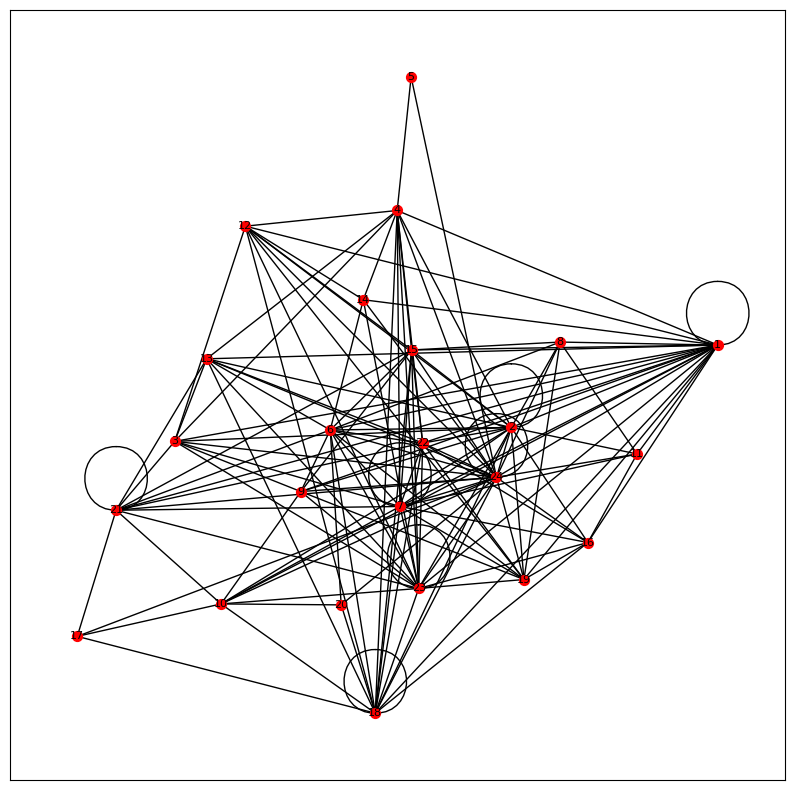

In [4]:

w_opt=4
x =[
-1.07, -0.95, -0.72, -0.75, 0.15, 0.28, 0.16, 0.01, 0.04, 0.50, 0.67, 0.95, 1.11, 0.54, 0.31, 0.35, -0.04, -0.21, 0.16, 0.43, 0.62, 0.40, 0.38, 0.28, 0.20, -0.14, -0.08, -0.30, -0.69, -1.08, -1.26, -1.07, -1.12, -1.13, -1.33, -1.73, -1.57, -1.36, -1.18, -0.98, -1.13, -1.17, -1.10, -1.00, -1.24, -1.15, -1.23, -0.92, -0.45, -0.19, 0.07, 0.38, 0.45, 0.85, 1.09, 1.23, 1.54, 1.90, 2.09, 1.80, 1.20, 0.27, -0.58, -0.97, -1.18, -1.54, -1.63, -1.66, -1.98, -2.37, -2.26, -2.09, -1.66, -1.45, -1.36, -1.29, -1.20, -0.90, -0.52, -0.64, -0.94, -1.09, -0.97, -0.45, -0.68, -1.09, -0.96, -1.13, -1.50, -1.39, -1.52, -1.66, -1.83, -1.66, -1.93, -2.01, -1.26, -0.82, -0.93, -0.74, -0.38, -0.16, 0.12, 0.30, 0.75, 0.71, 0.49, 0.78, 0.37, 0.19, -0.38, -0.21, 0.01, 0.09, -0.01, 0.40, 0.63, 0.48, 0.70, 0.62, 0.25, -0.20, -0.70, -0.74, -0.71, -0.55, -0.79, -0.71, -0.46, -0.38, -0.06, -0.13, -0.22, -0.02, 0.02, -0.25, -0.29, -0.47, -0.10, 0.28, 0.11, 0.29, 0.52, 0.54, 0.22, 0.03, -0.07, 0.08, 0.21, -0.06, -0.38, -0.28, -0.26, -0.10, 0.05, -0.36, -0.64, -0.64, -0.53, -0.57, -0.46, -0.64, -0.53, -0.19, -0.30, -0.41, -0.20, 0.13, -0.17, 0.13, 0.21, 0.45, 0.53, 0.37, 0.73, 1.49, 1.99, 1.92, 2.20, 2.35, 1.94, 1.38, 0.95, 0.90, 0.54, -0.11, -0.27, -0.52, -1.16, -1.29, -1.03, -0.67, -0.19, -0.52, -0.68, -0.73, -0.90, -0.50, -0.24, -0.34, -0.67, -1.19, -1.34, -1.16, -0.72, -0.79, -1.18, -1.03, -0.91, -0.74, -0.56, -0.70, -0.49, -0.37, -0.41, -0.66, -0.71, -0.42, -0.33, -0.53, -0.31, -0.11, 0.32, 0.53, 0.81, 1.01, 1.12, 1.14, 1.13, 0.98, 0.58, 0.62, 0.92, 1.29, 1.57, 1.65, 1.24, 1.07, 0.94, 0.90, 0.28, 0.10, -0.44, -1.25, -1.74, -1.74, -1.19, -1.00, -1.90, -2.05, -1.96, -1.97, -1.47, -1.21, -1.08, -0.88, -0.59, -0.57, -0.53, -0.30, -0.40, -0.45, -0.13, 0.01, 0.21, 0.04, 0.08, 0.08, -0.08, 0.09, 0.22, 0.22, 0.21, 0.10, 0.35, 0.49, 0.32, 0.03, 0.19, 0.26, 0.52, 0.76, 0.68, 0.42, 0.86, 1.20, 1.69, 1.84, 1.78, 1.38, 1.20, 1.04, 0.58, 0.22, 0.05, -0.06, -0.30, -0.28, -0.15, 0.14, 0.41, 0.39, 0.59, 0.78, 0.35, 0.23, 0.13, 0.35, 0.06, 0.00, 0.16, 0.10, 0.06, 0.11, 0.26, 0.31, 0.32, 0.24, 0.53, 0.48, 0.75, 1.11, 1.25, 1.02, 0.73, 0.46, 0.28, -0.11, -0.14, -0.21, -0.63, -0.84, -0.88, -1.10, -0.95, -0.86, -0.86, -0.61, -0.47, -0.38, -0.44, -0.44, -0.22, -0.45, -0.44, -0.41, -0.64, -0.53, -0.37, -0.25, 0.16, 0.64, 1.09, 1.56, 1.89, 2.13, 2.36, 2.41, 2.29, 2.38, 2.03, 1.34, 0.78, 0.57, -0.39, -0.99, -1.28, -1.26, -1.46, -1.46, -1.69, -1.69, -1.32, -0.95, -1.11, -1.15, -1.19, -1.17, -1.22, -1.09, -1.23, -1.58, -1.74, -1.77, -1.55, -0.98, -0.87, -0.86, -0.79, -0.67, -0.49, -0.52, -0.70, -0.79, -0.92, -0.73, -0.63, -0.48, -0.49, -0.34, -0.19, -0.04, -0.05, -0.20, -0.14, -0.37, -0.41, -0.15, -0.04, 0.01, 0.02, 0.31, 0.72, 0.74, 0.87, 1.09, 1.25, 1.47, 1.37, 0.60, 0.64, 0.36, -0.14, -0.61, -0.29, 0.21, 0.26, 0.27, 0.42, 0.33, 0.43, 0.27, 0.23, 0.12, 0.07, 0.06, 0.13, 0.49, 0.76, 0.81, 0.73, 0.66, 0.74, 0.66, 0.36, 0.45, 0.26, 0.30, 0.04, -0.23, -0.05, -0.04, -0.06, -0.59, -0.92, -0.91, -0.67, -0.71, -0.32, -0.09, 0.00, 0.01, 0.31, 0.60, 0.70, 0.99, 1.14, 0.70, 0.13, -0.18, -0.32, -0.47, -0.35, -0.59, -0.72, -1.11, -1.39, -1.54, -1.58, -1.68, -1.67, -1.21, -0.99, -0.84, -0.68, -0.30, -0.13, -0.25, -0.35, -0.46, -0.86, -0.89, -0.79, -0.69, -0.35, 0.06, 0.31, 0.48, 0.56, 0.68, 0.89, 1.46, 1.74, 1.52, 1.25, 0.90, 0.38, -0.22, -0.69, -1.07, -1.39, -1.60, -1.69, -1.64, -1.60, -1.54, -1.11, -0.93, -0.77, -0.52, -0.38, -0.43, -0.65, -0.80, -1.05, -1.19, -1.06, -0.87, -0.67, -0.61, -0.50, -0.32, 0.02, 0.25, 0.47, 0.38, 0.26, 0.16, -0.25, -0.53, -0.52, -0.25, -0.25, -0.40, -0.42, -0.39, -0.38, -0.18, -0.20, -0.14, -0.17, -0.49, -0.62, -0.28, 0.08, 0.32, 0.23, -0.06, -0.03, 0.29, 0.44, 0.75, 0.71, 0.51, 0.42, 0.47, 0.70, 0.92, 1.18, 1.46, 1.93, 2.21, 2.36, 2.72, 2.66, 2.57, 2.26, 1.62, 0.91, 0.30, -0.03, -0.48, -0.58, -0.58, -0.74, -0.76, -0.50, -0.43, -0.08, 0.03, 0.22, 0.37, 0.34, 0.25, -0.16, -0.43, -0.56, -0.97, -0.98, -0.98, -0.78, -0.80, -0.51, -0.20, 0.04, 0.12, 0.09, 0.47, 0.90, 0.90, 0.89, 0.65, 0.71, 0.81, 0.62, 0.55, 0.45, 0.35, 0.04, 0.03, 0.48, 0.52, 0.52
]

nodos = crear_ind(x , w_opt)
print("len() de nodos es",len(nodos))

G, unique_nodes, nodo_a_sublista= crear_grafo(nodos, w_opt)
A = nx.to_numpy_array(G)
print(unique_nodes)
print("len() de unique_nodes es",len(unique_nodes))
# Dibujar el grafo
plt.figure(figsize=(10, 10))
pos = nx.kamada_kawai_layout(G)  # Layout para la visualización
nx.draw_networkx_nodes(G, pos, node_size=50, node_color="red")
nx.draw_networkx_edges(G, pos, edge_color="black")
# Etiquetas con índices 1‑based
labels = {i: i+1 for i in G.nodes()}
nx.draw_networkx_labels(G, pos, labels, font_size=8)
#nx.draw_networkx_labels(G, pos, {i: f"{i}" for i in G.nodes()}, font_size=8)
#MU,MUT,MC=calcular_entropia(unique_nodes,nodos)
#for i in range(len(MC)):
 #   print(MC[i])
#plt.title("Grafo")
def calcular_grado_medio(G):
    grados = [grado for _, grado in G.degree()]  # Obtener los grados de todos los nodos
    grado_medio = np.mean(grados)  # Calcular el grado medio
    return grado_medio
#G, unique_nodes = crear_grafo(nodos, w_opt)
grado_medio = calcular_grado_medio(G)
distancia_media=nx.average_shortest_path_length(G)
print(f"El grado medio de la red es: {grado_medio}")
print((f"La distancia minima promedio de la red es: {distancia_media}"))
print("la distancia maxima es:",nx.diameter(G))
print(A)
plt.show()

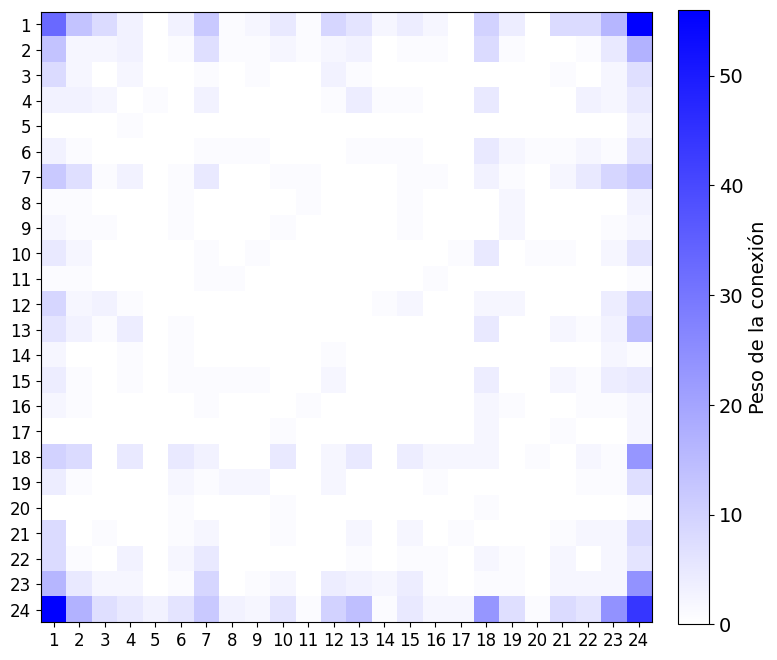

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

C = nx.adjacency_matrix(G).toarray()
plt.rcParams.update({
    'font.size': 14,
    'axes.titlesize': 14,
    'axes.labelsize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 14
})

fig, ax = plt.subplots(figsize=(8, 8))
azul_personalizado = LinearSegmentedColormap.from_list(
    'azul_personalizado',
    [(1, 1, 1), (0, 0, 1)]  # Blanco → Azul
)

im = ax.imshow(C, cmap=azul_personalizado, interpolation='nearest')
plt.xticks(ticks=range(24), labels=range(1, 25))
plt.yticks(ticks=range(24), labels=range(1, 25))

# Mantener proporción cuadrada
ax.set_aspect('equal')

# Barra de color a la derecha
cbar = fig.colorbar(
    im,
    ax=ax,
    fraction=0.046,   # ancho de la barra
    pad=0.04          # separación con la figura
)

cbar.ax.tick_params(labelsize=14)
cbar.set_label('Peso de la conexión', fontsize=14)

plt.tight_layout()
plt.savefig("matriz_adyacencia_nino34_obidos.png", dpi=300, bbox_inches='tight')

plt.show()

In [6]:
from matplotlib.colors import ListedColormap

A = np.array(A, dtype=int)
#A1 = np.array(A1, dtype=int)
print("NIÑO 3.4")
print(A)

cmap = ListedColormap(['white', 'blue'])
#plt.imshow(A, cmap=cmap, interpolation='nearest')

#plt.imshow(A, cmap='gray_r', interpolation='nearest')

NIÑO 3.4
[[33 13  8  3  0  3 12  1  2  5  1  9  6  2  4  2  0 10  4  0  8  8 16 56]
 [13  2  2  3  0  1  7  1  1  2  1  2  3  0  1  1  0  8  1  0  0  1  5 17]
 [ 8  2  0  2  0  0  1  0  1  0  0  3  1  0  0  0  0  0  0  0  1  0  2  7]
 [ 3  3  2  0  1  0  3  0  0  0  0  1  4  1  1  0  0  5  0  0  0  3  2  5]
 [ 0  0  0  1  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  3]
 [ 3  1  0  0  0  0  1  1  1  0  0  0  1  1  1  0  0  5  2  1  1  2  1  6]
 [12  7  1  3  0  1  5  0  0  1  1  0  0  0  1  1  0  3  1  0  2  5  9 12]
 [ 1  1  0  0  0  1  0  0  0  0  1  0  0  0  1  0  0  0  2  0  0  0  0  3]
 [ 2  1  1  0  0  1  0  0  0  1  0  0  0  0  1  0  0  0  2  0  0  0  1  2]
 [ 5  2  0  0  0  0  1  0  1  0  0  0  0  0  0  0  1  5  0  1  1  0  2  6]
 [ 1  1  0  0  0  0  1  1  0  0  0  0  0  0  0  1  0  0  0  0  0  0  0  1]
 [ 9  2  3  1  0  0  0  0  0  0  0  0  0  1  2  0  0  2  2  0  0  0  4 10]
 [ 6  3  1  4  0  1  0  0  0  0  0  0  0  0  0  0  0  5  0  0  2  1  3 14]
 [ 2  0  0  1  0

In [7]:
nodos_activos = contar_nodos_activos(G)
print(f"Nodos activos: {nodos_activos} de {NUM_NODOS_GLOBAL} posibles")
print(f"Porcentaje: {100*nodos_activos/NUM_NODOS_GLOBAL:.2f}%")

Nodos activos: 24 de 24 posibles
Porcentaje: 100.00%


#Mapeo anomalias caudal Obidos

len() de nodos es 620
{(1, 2, 3, 4): 0, (1, 2, 4, 3): 1, (1, 3, 2, 4): 2, (1, 3, 4, 2): 3, (1, 4, 2, 3): 4, (1, 4, 3, 2): 5, (2, 1, 3, 4): 6, (2, 1, 4, 3): 7, (2, 3, 1, 4): 8, (2, 3, 4, 1): 9, (2, 4, 1, 3): 10, (2, 4, 3, 1): 11, (3, 1, 2, 4): 12, (3, 1, 4, 2): 13, (3, 2, 1, 4): 14, (3, 2, 4, 1): 15, (3, 4, 1, 2): 16, (3, 4, 2, 1): 17, (4, 1, 2, 3): 18, (4, 1, 3, 2): 19, (4, 2, 1, 3): 20, (4, 2, 3, 1): 21, (4, 3, 1, 2): 22, (4, 3, 2, 1): 23}
len() de unique_nodes es 24


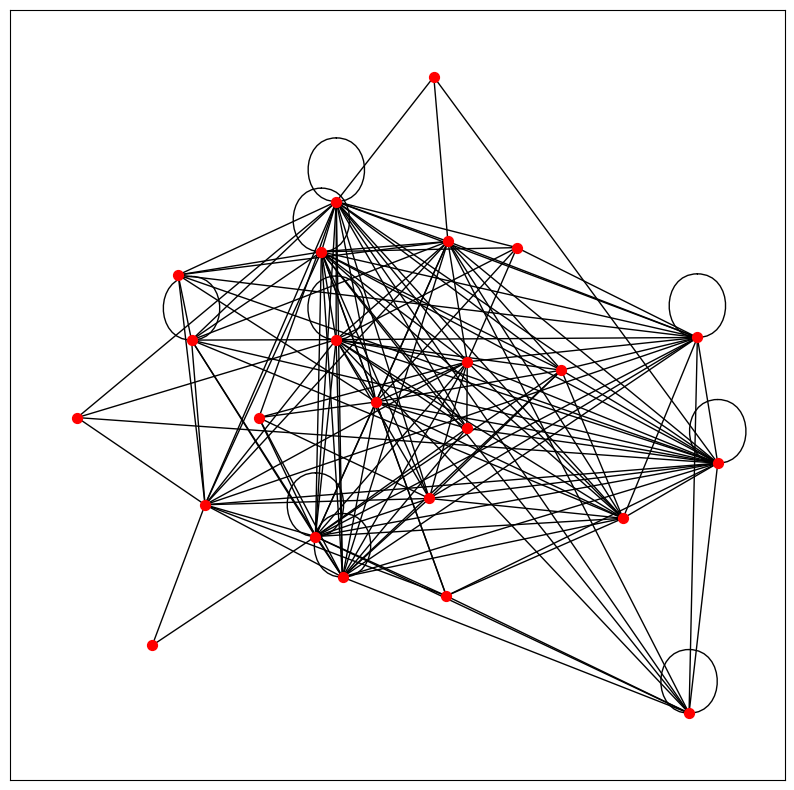

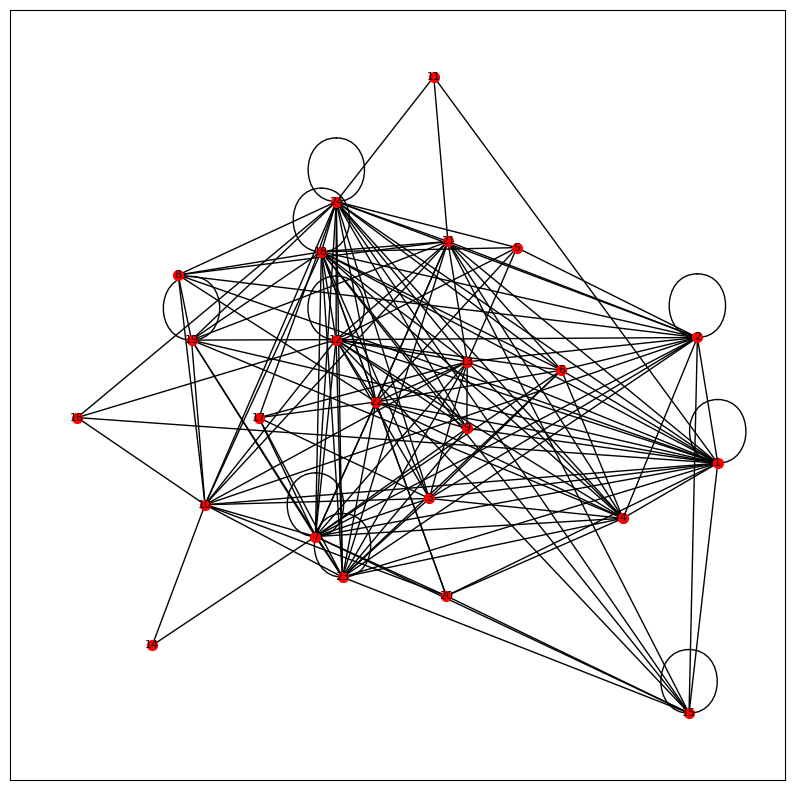

El grado medio de la red es: 12.833333333333334
La distancia minima promedio de la red es: 1.4818840579710144
la distancia maxima es: 3
[[ 8.  6.  4. 10.  0.  2. 10.  3.  1.  7.  3.  8.  9.  0.  7.  4.  0. 27.
   4.  2.  7.  4. 21. 63.]
 [ 6.  3.  3.  1.  1.  1.  5.  2.  0.  2.  0.  2.  7.  0.  2.  0.  0.  7.
   0.  0.  4.  0.  7. 23.]
 [ 4.  3.  0.  1.  0.  1.  1.  0.  0.  1.  0.  1.  1.  0.  0.  0.  1.  2.
   0.  0.  0.  0.  1.  5.]
 [10.  1.  1.  0.  0.  1.  4.  0.  0.  0.  0.  2.  5.  0.  0.  0.  0.  3.
   2.  1.  4.  2.  6. 13.]
 [ 0.  1.  0.  0.  0.  0.  0.  0.  0.  0.  0.  1.  1.  0.  0.  0.  0.  1.
   0.  0.  0.  1.  0.  1.]
 [ 2.  1.  1.  1.  0.  0.  2.  0.  0.  0.  0.  1.  0.  0.  0.  0.  0.  3.
   0.  0.  1.  1.  3.  5.]
 [10.  5.  1.  4.  0.  2.  2.  0.  1.  1.  0.  9.  1.  1.  2.  0.  1.  7.
   2.  3.  5.  1.  6. 22.]
 [ 3.  2.  0.  0.  0.  0.  0.  0.  0.  1.  0.  0.  0.  0.  0.  0.  0.  1.
   1.  0.  2.  1.  0.  1.]
 [ 1.  0.  0.  0.  0.  0.  1.  0.  0.  0.  0.  1.  1.  0

In [8]:

w_opt=4
x1 =[
    -1.178619455, -1.587511821, -1.996334256, -1.5000797, -1.596829621,
    -1.837116066, -1.464845475, -0.5656073867, 0.7946559729, 1.039236247,
    0.2760321902, -0.3282719233, -0.8837335073, -1.168315223, -1.117777129,
    -0.8303637819, -1.404491283, -1.61464756, -1.470148494, -1.011568582,
    -0.5954865161, -0.6613435031, -1.484885378, -1.754020104, -1.350142808,
    -0.8317590174, -0.6435089624, -0.3397016133, -0.4312908284, -0.3901349111,
    -0.2283983469, 0.06464861589, 0.5134902235, -0.236332062, -1.332926899,
    -1.646233034, -0.7021437671, -0.2024645677, 0.4370336013, 0.6014203942,
    0.7407117932, 0.6855751852, 0.6459971996, 0.8892738503, 1.280962049,
    1.349564017, 0.9688493087, -0.4531781158, 0.1617415167, 0.556571015,
    0.3373132322, 0.3829715906, 0.2789421297, 0.1221843891, 0.07218642129,
    0.4962369655, 1.153611448, 0.6592849729, 0.272927376, -0.1198835886,
    -0.8024128845, -0.8741496846, -0.9829081133, -0.4892090723, 0.06358625386,
    0.2306110468, 0.5583768602, 1.138716603, 2.0680016, 1.926679195,
    1.515961931, 0.8144823625, 0.8770948327, 0.7576769074, 0.7827944982,
    0.720412832, 0.5294549311, 0.3778092591, 0.507154516, 0.96946627,
    1.668627546, 1.906141288, 1.216347357, 0.5773508092, 0.5709582163,
    0.5535736951, 0.874403641, 0.9986000371, 1.05412869, 0.8676677966,
    1.01070029, 1.499246678, 1.835755162, 0.8124977568, -0.06594092014,
    -0.1200949358, 0.4611331769, 0.4727887872, 1.101358931, 1.512188836,
    1.313785445, 1.014197534, 0.5494581462, 0.374672242, 0.2369758185,
    -0.2380161704, -0.500836685, -0.4607866148, -0.909195547, -1.089956717,
    -0.7109434704, 0.1275495601, 0.4009666157, 0.283286883, 0.03964516732,
    0.02958961831, 0.5276046479, 1.499285357, 1.542574624, 1.512984843,
    0.4677283965, 0.1452245409, -0.01496845437, 0.07233190245, 0.0303211808,
    -0.1329057009, -0.2057399922, -0.1058106482, 0.3348144421, 0.8597349422,
    0.5062319882, 0.8770411324, 0.190014522, -0.3182182077, -0.09337697422,
    0.2622031464, 0.2907662078, -0.1605805692, -0.7514688736, -0.9243912279,
    -0.7630953057, -0.3788240587, -0.875343813, -0.8606555086, -1.20829454,
    -1.769777417, -2.268298899, -2.587641519, -2.3546742, -1.95343073,
    -1.723608705, -1.6012851, -0.9001014569, 0.3091547396, 0.1651459677,
    -0.6905210163, -0.8154399746, -0.9547918629, -1.015989193, -1.607608823,
    -1.765677456, -1.393783394, -1.036385631, -0.8948395824, -0.7941470393,
    -0.6756173482, -0.9041076992, -0.05140709725, 0.7180064298, 0.6209420281,
    0.6555595775, 1.101124051, 0.9153928404, 0.4339611657, 0.001318801532,
    -0.02615553111, 0.03744918286, -0.03407475696, 0.1897627091, 0.03038426739,
    -0.5908213611, -1.377413969, -1.830769816, -2.301381557, -2.211366373,
    -2.203841494, -2.299106808, -2.028601894, -1.069634941, -0.5718598436,
    -0.5141430317, -0.3126322308, -0.2790560072, -0.05088581836, 0.0365616885,
    0.2859370519, -0.04897896968, -0.1853141471, -0.2062220849, 0.02515687148,
    0.3765161505, 0.5498179302, 0.2735926933, 0.5887635578, 0.7107033642,
    -0.4689405798, -1.55085299, -1.895806247, -1.646490749, -1.382553013,
    -0.9955282784, -0.2297932336, 0.4992154079, 0.8203021614, 0.8051812442,
    0.5221891912, -0.11039807, -0.05002944125, 0.1044733274, -0.02179644382,
    -0.1645396263, 0.2020003134, 0.3481844642, 0.3323596588, 0.9361209991,
    1.975354034, 1.930232858, 1.065985525, 0.3917370378, 0.2402824006,
    0.005707220239, -0.2458961773, -0.7045058597, -1.01943735, -1.172456281,
    -1.001225506, -0.6689456794, -0.4352622262, -0.4312001372, -0.3975938034,
    -0.2169289026, 0.0100596863, -0.5526950378, -0.5644471673, -0.4087462528,
    -0.3537698668, -0.4652263619, -0.7184699892, -0.7855661109, -0.2186078486,
    0.5743161289, 0.3085171766, 0.5614839689, 1.156034995, 1.569742482,
    1.564338846, 1.58999591, 1.328514516, 1.110613992, 1.126895945,
    1.113192869, 1.582669258, 0.8187093634, -1.080245245, -0.7868198525,
    0.127383351, -0.0491628393, -0.2544532997, -0.3636571016, -0.3238221833,
    -0.1906745969, -0.07182625593, -0.4151105881, -0.7214990318,
    -0.05571721042, 0.4710431699, 0.579642943, -0.4028568125, -0.3060183354,
    -0.132070304, 0.02669513018, -0.1076373429, 0.04892545086, 0.06854406007,
    -0.3912443796, -1.059285983, -1.278659182, -1.942753149, -2.108756408,
    -2.007707525, -1.619400804, -2.154295925, -2.776084343, -2.815496191,
    -2.260418873, -1.496887196, -0.3835776809, -0.4662744653, -0.0814649913,
    0.334935576, 0.2020547113, 0.4166960862, 0.6463350458, 0.4565951342,
    0.1206571375, -0.09734282672, -0.2461152518, -0.1345563397, 0.2919899954,
    0.6857788725, 1.580941257, 1.950262191, 1.807742252, 1.506721424,
    1.278851645, 0.9732515802, 0.8228497225, 0.8117832801, 0.646238246,
    0.8746323532, 1.259790413, 0.6937886561, 0.161819381, 0.1358465179,
    -0.6824057518, -1.213132292, -1.371451752, -0.9102840759, -0.6781775792,
    -0.7857384626, -0.9511757545, -1.633388933, -1.691840469, -1.260023483,
    -0.2265041704, -0.138693489, -0.07228328196, 0.3757327143, 0.7381032323,
    0.6193419147, 0.4375424307, 0.1669722193, 0.006983390186, -0.01057375441,
    0.009541116467, 0.4923117915, 0.5162117483, -0.05964963787, -0.2201414348,
    0.05687496857, 1.076707165, 1.360421004, 0.766251802, -0.01792798739,
    -0.5655016334, -1.098531015, -1.65998678, -1.688156686, -1.558314235,
    -1.499346733, -1.736613146, -1.684282435, -1.967865443, -1.762928667,
    -1.302331249, -0.8755815131, -0.7484557946, -0.9573010149, -1.354024553,
    -0.9673993886, -0.09632374512, -0.5630786574, 0.06270432368, 0.766097949,
    0.8850595656, 1.060437356, 1.317096187, 0.989998736, 0.8766785333,
    0.9220493116, 0.4533435287, -0.4286900961, -1.292963504, -0.7949265309,
    -0.6218985258, -0.3380576108, 0.2011718671, 0.6982934779, 0.596300386,
    0.5362378527, 0.6414173194, 0.8501850829, 1.110947392, 0.8866396,
    -0.3036809813, -0.4698745442, 0.1904092823, 0.4730742463, 0.9405657998,
    0.5575045963, 0.218875813, 0.03581740892, -0.2751613341, -0.2695536293,
    -0.2830124072, -0.6238207476, -0.6630410513, 0.2628661824, -0.3332402621,
    -0.2191639214, -0.1237543115, -0.1451481703, 0.1903403711, 0.3673810479,
    0.4069997677, 0.5753547799, 0.3713675934, -0.1489021933, 0.2567379875,
    -0.1281261292, -0.6383899778, -0.9449435261, -0.7002875458, -0.4546576725,
    -0.341112526, -0.2052347044, 0.01542001159, 0.375478196, 0.4124437762,
    0.2741992225, -0.4802118476, -0.7794981856, -0.4797303663, -0.6487797739,
    -0.5215224822, -0.6517943977, -1.08256105, -1.207813627, -0.8504183903,
    -0.2874189422, 0.3442775221, 0.3415635564, 0.03008654859, -0.3855470133,
    -0.7876093731, 0.01177244053, 0.6154805775, 0.4659595323, -0.2015884044,
    -0.8965716306, -1.414225746, -1.841875792, -1.713268732, -0.9793935261,
    -0.1604159818, 0.4015099426, 0.877489593, 1.364848282, 1.382070974,
    1.81265685, 1.460876977, 0.4498708726, -0.340966981, -0.706649331,
    -0.8013967209, -0.4127526805, 0.2645000231, 0.3157029813, 0.1582363175,
    -0.2410015378, -0.393174256, 0.1084978537, 0.414524892, 0.09170192548,
    -0.0936534508, -0.4072374321, -0.5005188948, -0.1160210047, 0.3137335059,
    1.526722411, 1.706343303, 1.492020283, 1.038377645, 0.5447496403,
    0.8122868794, 1.165941377, 0.8990958416, 0.1808403129, -0.1008080196,
    0.2347664416, 1.172879958, 2.383312594, 2.55620779, 2.103188084,
    1.237818383, 0.3009523798, 0.5269324611, 1.288138621, 2.139881803,
    1.934193169, 0.4121871503, -0.8718159709, -1.580092289, 0.06018422195,
    0.05046675423, -0.3681735393, 0.07282364089, 0.7334906982, 0.7210049964,
    0.564714891, -0.05797859459, -1.244892256, -2.372765211, -2.583239735,
    -1.696545, -1.241503155, -0.4828544177, 0.1586411157, 0.5303922243,
    0.4801675845, 0.8278946625, 1.162465306, 0.9305523871, -0.3624129589,
    -1.178235813, -0.7269826529, -0.5279372778, 0.6118004021, 1.685951891,
    1.758496295, 1.122193649, 0.6225710175, 0.7992015663, 1.360200234,
    1.263678409, 0.1093790611, -1.018213526, -1.412948736, -1.848148644,
    -0.525881551, 0.1414590045, 0.967917489, 0.7982217323, 0.3558471272,
    0.7071314114, 1.182653254, 1.205947814, 1.325026295, 1.232203129,
    1.088937981, 1.617755483, 1.299312829, 0.908478277, 0.9205312887,
    0.6215242362, 0.134330676, 0.3662826533, 1.02770073, 1.801332239,
    1.900880405, 1.400293092, 0.9706396383, 1.103686955, 0.6796428518,
    0.7748519137, 0.8495947177, 0.7482820259, 0.2232924578, 0.4055385926,
    1.02743334, 1.758425993, 2.019221313, 0.2220915164, -1.614774745,
    -2.303647069, -2.421031853, -2.334205379, -1.898662173, -1.323102482,
    -0.9488718542, -0.6570518929, -0.389332741, -0.1657263022, -0.177674877,
    -0.7511782405, -0.6023175593, 0, 0.1971372046, 1.147308261, 1.310182876,
    0.7945637283, 0.366018801, 0.5250406086, 0.7494814028, 0.3516796359,
    -0.7435754553, -1.164538406, -0.3833013223, -0.04886444187, 0.2161584522,
    0.4900323538, 0.168632182, -0.1943696925, -0.02066625784, 0.3019596684,
    0.7044261825, 0.8665545877, 1.061747999, 0.205410833, -0.9201827411,
    1.130521421, 2.081297452, 1.882154569, 1.369415626, 0.7150419029,
    0.3156447975, 0.5668190179, 1.121287241, 1.476160745, 1.408308205,
    0.253816893, 0.4793729103, 1.107176175
]

nodos1 = crear_ind(x1 , w_opt)
print("len() de nodos es",len(nodos1))

G1, unique_nodes1, nodo_a_sublista1= crear_grafo(nodos1, w_opt)
A1 = nx.to_numpy_array(G1)
print(unique_nodes1)
print("len() de unique_nodes es",len(unique_nodes1))
# Dibujar el grafo
plt.figure(figsize=(10, 10))
pos = nx.kamada_kawai_layout(G1)  # Layout para la visualización
nx.draw_networkx_nodes(G1, pos, node_size=50, node_color="red")
nx.draw_networkx_edges(G1, pos, edge_color="black")
plt.figure(figsize=(10, 10))
pos = nx.kamada_kawai_layout(G1)
nx.draw_networkx_nodes(G1, pos, node_size=50, node_color="red")
nx.draw_networkx_edges(G1, pos, edge_color="black")
labels = {i: i+1 for i in G1.nodes()}
nx.draw_networkx_labels(G1, pos, labels, font_size=8)
plt.show()
#nx.draw_networkx_labels(G, pos, {i: f"{i}" for i in G.nodes()}, font_size=8)
#MU,MUT,MC=calcular_entropia(unique_nodes,nodos)
#for i in range(len(MC)):
 #   print(MC[i])
#plt.title("Grafo")
def calcular_grado_medio(G1):
    grados = [grado for _, grado in G1.degree()]  # Obtener los grados de todos los nodos
    grado_medio = np.mean(grados)  # Calcular el grado medio
    return grado_medio
#G, unique_nodes = crear_grafo(nodos, w_opt)
grado_medio = calcular_grado_medio(G1)
distancia_media=nx.average_shortest_path_length(G1)
print(f"El grado medio de la red es: {grado_medio}")
print((f"La distancia minima promedio de la red es: {distancia_media}"))
print("la distancia maxima es:",nx.diameter(G1))
print(A1)
plt.show()

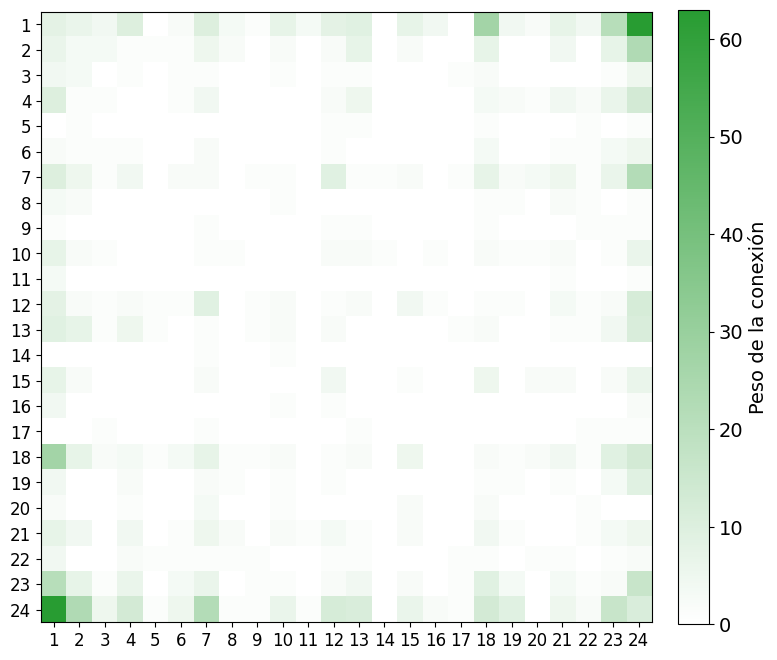

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap,to_rgb

C = nx.adjacency_matrix(G1).toarray()
plt.rcParams.update({
    'font.size': 14,
    'axes.titlesize': 14,
    'axes.labelsize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 14
})
fig, ax = plt.subplots(figsize=(8, 8))
# Blanco → Verde
color_hex = '#289c32'  # Cambia este valor por el hexadecimal que desees
verde_personalizado = LinearSegmentedColormap.from_list(
    'verde_personalizado',                # nombre del mapa
    [(1, 1, 1), to_rgb(color_hex)]        # blanco → color hexadecimal
)


im = ax.imshow(C, cmap=verde_personalizado, interpolation='nearest')
plt.xticks(ticks=range(24), labels=range(1, 25))
plt.yticks(ticks=range(24), labels=range(1, 25))

# Mantener proporción cuadrada
ax.set_aspect('equal')

# Barra de color a la derecha
cbar = fig.colorbar(
    im,
    ax=ax,
    fraction=0.046,   # ancho de la barra
    pad=0.04          # separación con la figura
)

cbar.ax.tick_params(labelsize=14)
cbar.set_label('Peso de la conexión', fontsize=14)

plt.tight_layout()
plt.savefig("matriz_adyacencia_obidos.png", dpi=300, bbox_inches='tight')

plt.show()

In [10]:
print(unique_nodes)
print(nodo_a_sublista)
print(unique_nodes1)
print(nodo_a_sublista1)

{(1, 2, 3, 4): 0, (1, 2, 4, 3): 1, (1, 3, 2, 4): 2, (1, 3, 4, 2): 3, (1, 4, 2, 3): 4, (1, 4, 3, 2): 5, (2, 1, 3, 4): 6, (2, 1, 4, 3): 7, (2, 3, 1, 4): 8, (2, 3, 4, 1): 9, (2, 4, 1, 3): 10, (2, 4, 3, 1): 11, (3, 1, 2, 4): 12, (3, 1, 4, 2): 13, (3, 2, 1, 4): 14, (3, 2, 4, 1): 15, (3, 4, 1, 2): 16, (3, 4, 2, 1): 17, (4, 1, 2, 3): 18, (4, 1, 3, 2): 19, (4, 2, 1, 3): 20, (4, 2, 3, 1): 21, (4, 3, 1, 2): 22, (4, 3, 2, 1): 23}
{0: (1, 2, 3, 4), 1: (1, 2, 4, 3), 2: (1, 3, 2, 4), 3: (1, 3, 4, 2), 4: (1, 4, 2, 3), 5: (1, 4, 3, 2), 6: (2, 1, 3, 4), 7: (2, 1, 4, 3), 8: (2, 3, 1, 4), 9: (2, 3, 4, 1), 10: (2, 4, 1, 3), 11: (2, 4, 3, 1), 12: (3, 1, 2, 4), 13: (3, 1, 4, 2), 14: (3, 2, 1, 4), 15: (3, 2, 4, 1), 16: (3, 4, 1, 2), 17: (3, 4, 2, 1), 18: (4, 1, 2, 3), 19: (4, 1, 3, 2), 20: (4, 2, 1, 3), 21: (4, 2, 3, 1), 22: (4, 3, 1, 2), 23: (4, 3, 2, 1)}
{(1, 2, 3, 4): 0, (1, 2, 4, 3): 1, (1, 3, 2, 4): 2, (1, 3, 4, 2): 3, (1, 4, 2, 3): 4, (1, 4, 3, 2): 5, (2, 1, 3, 4): 6, (2, 1, 4, 3): 7, (2, 3, 1, 4): 8, 

In [11]:
nodos_activos = contar_nodos_activos(G1)
print(f"Nodos activos: {nodos_activos} de {NUM_NODOS_GLOBAL} posibles")
print(f"Porcentaje: {100*nodos_activos/NUM_NODOS_GLOBAL:.2f}%")

Nodos activos: 24 de 24 posibles
Porcentaje: 100.00%


## W OPTIMO

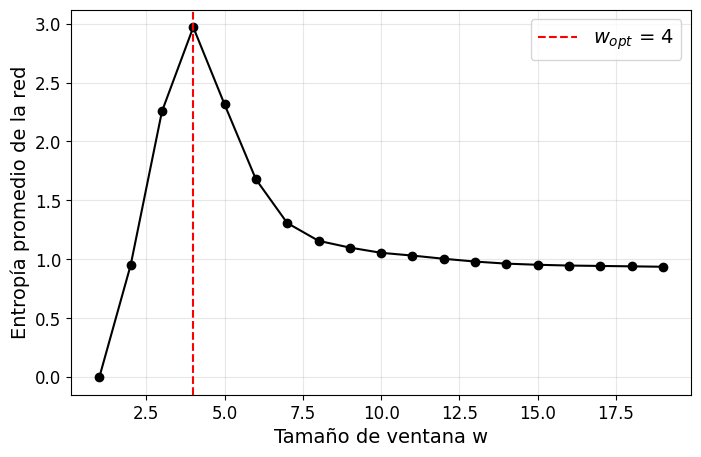

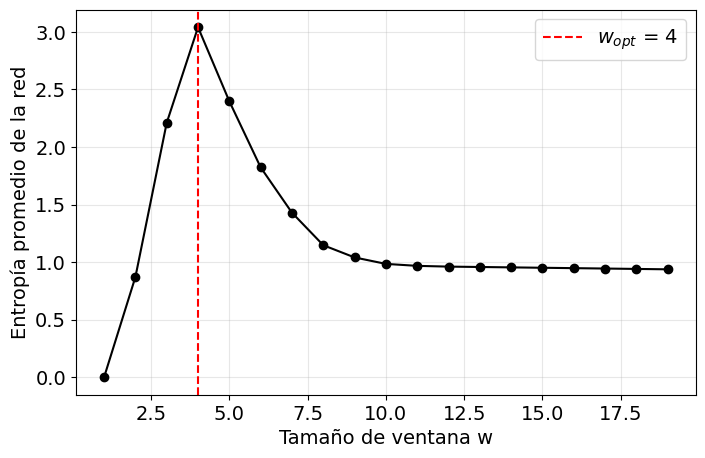

4
4


In [12]:
ventana=optimizar_w(x,1,20)
ventana1=optimizar_w(x1,1,20)
print(ventana)
print(ventana1)

##INTERSECCIÓN

NIÑO 3.4
[[33 13  8  3  0  3 12  1  2  5  1  9  6  2  4  2  0 10  4  0  8  8 16 56]
 [13  2  2  3  0  1  7  1  1  2  1  2  3  0  1  1  0  8  1  0  0  1  5 17]
 [ 8  2  0  2  0  0  1  0  1  0  0  3  1  0  0  0  0  0  0  0  1  0  2  7]
 [ 3  3  2  0  1  0  3  0  0  0  0  1  4  1  1  0  0  5  0  0  0  3  2  5]
 [ 0  0  0  1  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  3]
 [ 3  1  0  0  0  0  1  1  1  0  0  0  1  1  1  0  0  5  2  1  1  2  1  6]
 [12  7  1  3  0  1  5  0  0  1  1  0  0  0  1  1  0  3  1  0  2  5  9 12]
 [ 1  1  0  0  0  1  0  0  0  0  1  0  0  0  1  0  0  0  2  0  0  0  0  3]
 [ 2  1  1  0  0  1  0  0  0  1  0  0  0  0  1  0  0  0  2  0  0  0  1  2]
 [ 5  2  0  0  0  0  1  0  1  0  0  0  0  0  0  0  1  5  0  1  1  0  2  6]
 [ 1  1  0  0  0  0  1  1  0  0  0  0  0  0  0  1  0  0  0  0  0  0  0  1]
 [ 9  2  3  1  0  0  0  0  0  0  0  0  0  1  2  0  0  2  2  0  0  0  4 10]
 [ 6  3  1  4  0  1  0  0  0  0  0  0  0  0  0  0  0  5  0  0  2  1  3 14]
 [ 2  0  0  1  0

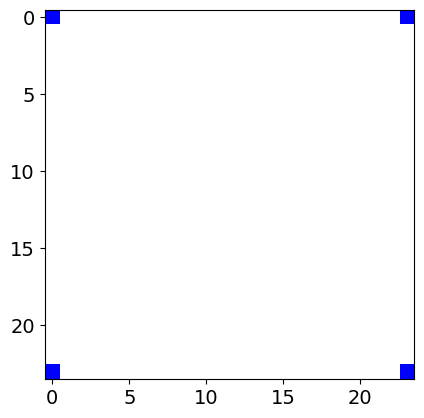

In [13]:
from matplotlib.colors import ListedColormap

A = np.array(A, dtype=int)
A1 = np.array(A1, dtype=int)
print("NIÑO 3.4")
print(A)


# contar diagonal (loops)
loops = np.count_nonzero(np.diag(A))

# contar fuera de la diagonal
off_diag = np.count_nonzero(A) - loops

# calcular M
M = off_diag / 2 + loops

print("M =", M)

cmap = ListedColormap(['white', 'blue'])
plt.imshow(A, cmap=cmap, interpolation='nearest')

#plt.imshow(A, cmap='gray_r', interpolation='nearest')



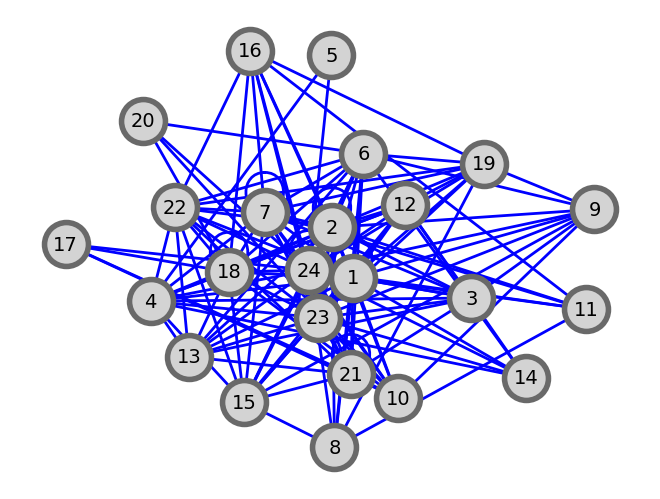

In [14]:
G = nx.from_numpy_array(A)
pos = nx.spring_layout(G, k=5, iterations=100)

# Crear un diccionario de etiquetas con índices 1‑based
labels = {i: i+1 for i in G.nodes()}

nx.draw(
    G, pos,
    labels=labels,                # Usar las etiquetas personalizadas
    node_color='lightgray',
    edgecolors="dimgray",
    node_size=1000,
    linewidths=4,
    edge_color='blue',
    width=2,
    font_size=14
)
plt.savefig("grafo_nino34_obidos.png", dpi=300, bbox_inches='tight')

plt.show()

CALAMAR
[[ 8  6  4 10  0  2 10  3  1  7  3  8  9  0  7  4  0 27  4  2  7  4 21 63]
 [ 6  3  3  1  1  1  5  2  0  2  0  2  7  0  2  0  0  7  0  0  4  0  7 23]
 [ 4  3  0  1  0  1  1  0  0  1  0  1  1  0  0  0  1  2  0  0  0  0  1  5]
 [10  1  1  0  0  1  4  0  0  0  0  2  5  0  0  0  0  3  2  1  4  2  6 13]
 [ 0  1  0  0  0  0  0  0  0  0  0  1  1  0  0  0  0  1  0  0  0  1  0  1]
 [ 2  1  1  1  0  0  2  0  0  0  0  1  0  0  0  0  0  3  0  0  1  1  3  5]
 [10  5  1  4  0  2  2  0  1  1  0  9  1  1  2  0  1  7  2  3  5  1  6 22]
 [ 3  2  0  0  0  0  0  0  0  1  0  0  0  0  0  0  0  1  1  0  2  1  0  1]
 [ 1  0  0  0  0  0  1  0  0  0  0  1  1  0  0  0  0  1  0  0  0  1  1  1]
 [ 7  2  1  0  0  0  1  1  0  0  0  2  2  1  0  1  0  2  1  1  2  0  1  6]
 [ 3  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  1  0  0  1]
 [ 8  2  1  2  1  1  9  0  1  2  0  1  2  0  4  1  0  1  1  0  3  1  2 12]
 [ 9  7  1  5  1  0  1  0  1  2  0  2  0  0  0  0  1  2  0  0  1  1  4 11]
 [ 0  0  0  0  0 

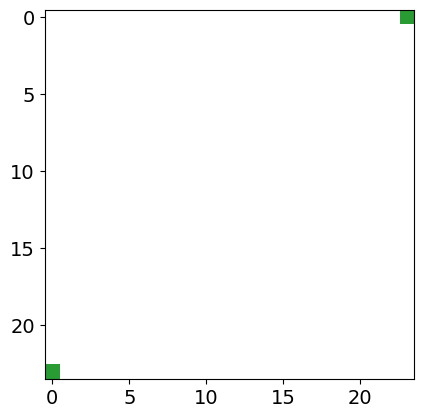

In [15]:
print("CALAMAR")
print(A1)


# contar diagonal (loops)
loops = np.count_nonzero(np.diag(A1))

# contar fuera de la diagonal
off_diag = np.count_nonzero(A1) - loops

# calcular M
M = off_diag / 2 + loops

print("M =", M)

cmap = ListedColormap(['white', '#289c32'])
plt.imshow(A1, cmap=cmap, interpolation='nearest')


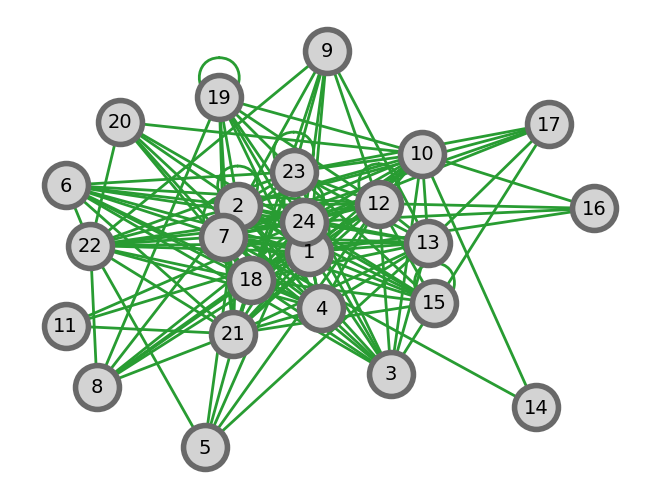

In [16]:
G1 = nx.from_numpy_array(A1)
pos = nx.spring_layout(G1, k=5, iterations=100)

# Crear un diccionario de etiquetas con índices 1‑based
labels = {i: i+1 for i in G1.nodes()}

nx.draw(
    G1, pos,
    labels=labels,                # Usar las etiquetas personalizadas
    node_color='lightgray',
    edgecolors="dimgray",
    node_size=1000,
    linewidths=4,
    edge_color='#289c32',
    width=2,
    font_size=14
)
plt.savefig("grafo_ordinal_obidos.png", dpi=300, bbox_inches='tight')

plt.show()

In [17]:
print(A.shape, A1.shape)

(24, 24) (24, 24)


##INTERSECCIÓN


In [18]:
C = np.divide(A1 ,A, out=np.zeros_like(A, dtype=float), where=A!=0) * 100
C_clean = np.where(np.isinf(C), 0, C)
#print(C_clean)
C_clean_beauty = np.array(C_clean, dtype=int)
print(C_clean_beauty)

[[ 24  46  50 333   0  66  83 300  50 140 300  88 150   0 175 200   0 270
  100   0  87  50 131 112]
 [ 46 150 150  33   0 100  71 200   0 100   0 100 233   0 200   0   0  87
    0   0   0   0 140 135]
 [ 50 150   0  50   0   0 100   0   0   0   0  33 100   0   0   0   0   0
    0   0   0   0  50  71]
 [333  33  50   0   0   0 133   0   0   0   0 200 125   0   0   0   0  60
    0   0   0  66 300 260]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0  33]
 [ 66 100   0   0   0   0 200   0   0   0   0   0   0   0   0   0   0  60
    0   0 100  50 300  83]
 [ 83  71 100 133   0 200  40   0   0 100   0   0   0   0 200   0   0 233
  200   0 250  20  66 183]
 [300 200   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   50   0   0   0   0  33]
 [ 50   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0 100  50]
 [140 100   0   0   0   0 100   0   0   0   0   0   0   0   0   0   0  40
    0 100 200   0

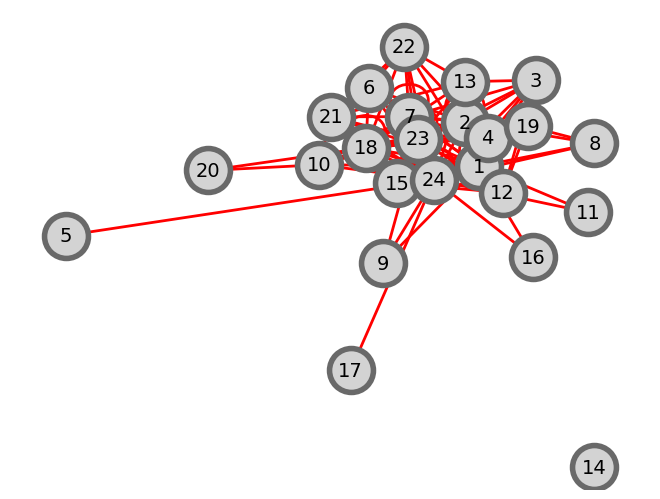

In [19]:
GC = nx.from_numpy_array(C_clean)
pos = nx.spring_layout(GC, k=5, iterations=100)

# Crear un diccionario de etiquetas con índices 1‑based
labels = {i: i+1 for i in GC.nodes()}

nx.draw(
    GC, pos,
    labels=labels,                # Usar las etiquetas personalizadas
    node_color='lightgray',
    edgecolors="dimgray",
    node_size=1000,
    linewidths=4,
    edge_color='red',
    width=2,
    font_size=14
)
plt.savefig("grafo_influencia_obidos.png", dpi=300, bbox_inches='tight')

plt.show()

INTERCEPCIÓN
M = 103.0


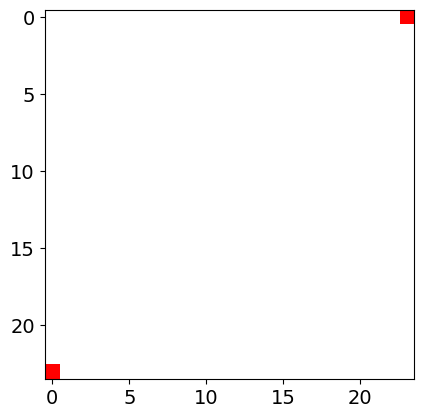

In [20]:
print("INTERCEPCIÓN")
#print(C_clean)


# contar diagonal (loops)
loops = np.count_nonzero(np.diag(C_clean))

# contar fuera de la diagonal
off_diag = np.count_nonzero(C_clean) - loops

# calcular M
M = off_diag / 2 + loops

print("M =", M)

cmap = ListedColormap(['white', 'red'])
plt.imshow(A1, cmap=cmap, interpolation='nearest')

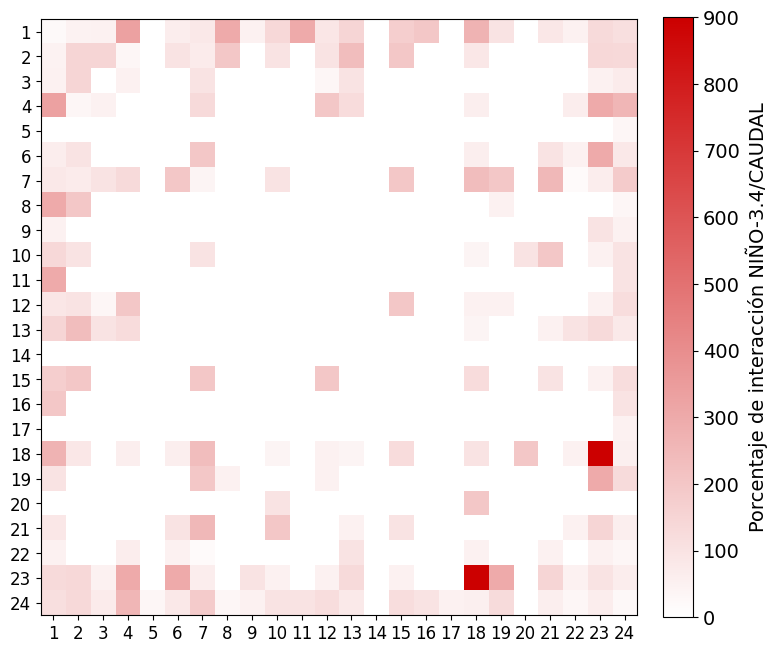

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

C = nx.adjacency_matrix(GC).toarray()
plt.rcParams.update({
    'font.size': 14,
    'axes.titlesize': 14,
    'axes.labelsize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 14
})

fig, ax = plt.subplots(figsize=(8, 8))
# Blanco → Rojo
rojo_personalizado = LinearSegmentedColormap.from_list(
    'rojo_personalizado',
    [(1, 1, 1), (0.8, 0, 0)]  # Blanco → Rojo
)

im = ax.imshow(C, cmap=rojo_personalizado, interpolation='nearest')
plt.xticks(ticks=range(24), labels=range(1, 25))
plt.yticks(ticks=range(24), labels=range(1, 25))

# Mantener proporción cuadrada
ax.set_aspect('equal')

# Barra de color a la derecha
cbar = fig.colorbar(
    im,
    ax=ax,
    fraction=0.046,   # ancho de la barra
    pad=0.04          # separación con la figura
)

cbar.ax.tick_params(labelsize=14)
cbar.set_label('Porcentaje de interacción NIÑO-3.4/CAUDAL', fontsize=14)

plt.tight_layout()
plt.savefig("matriz_influencia_obidos.png", dpi=300, bbox_inches='tight')

plt.show()



In [22]:
nodos_activos = contar_nodos_activos(GC)
print(f"Nodos activos: {nodos_activos} de {NUM_NODOS_GLOBAL} posibles")
print(f"Porcentaje: {100*nodos_activos/NUM_NODOS_GLOBAL:.2f}%")

Nodos activos: 23 de 24 posibles
Porcentaje: 95.83%


#PORCENTAJE DE INTERACCIÓN

In [23]:
upper = np.triu(C_clean)
promedio = np.mean(upper)
print("La influencia del NIÑO 3.4 en el caudal es:",promedio,"%")

La influencia del NIÑO 3.4 en el caudal es: 21.948526069553214 %


##MÉTRICAS

In [24]:
import networkx as nx
import numpy as np

# Intento de importar correctamente python-louvain
try:
    import community.community_louvain as community_louvain
except ImportError:
    import community as community_louvain

def calcular_metricas_red(G, nombre_grafo):
    """
    Calcula e imprime métricas de red considerando solo nodos activos.
    Las etiquetas en pantalla se muestran como 1‑based.
    """
    print(f"\n=== Métricas para {nombre_grafo} ===")

    # Identificar nodos activos (grado > 0)
    nodos_activos = [n for n in G.nodes() if G.degree(n) > 0]
    num_activos = len(nodos_activos)
    print(f"Nodos activos: {num_activos} de {G.number_of_nodes()}")

    if num_activos == 0:
        print("No hay nodos activos. No se pueden calcular métricas.")
        return

    # Subgrafo inducido por los nodos activos
    G_activo = G.subgraph(nodos_activos).copy()

    # ---- Grado medio (solo activos) ----
    grados = [d for n, d in G_activo.degree()]
    grado_medio = np.mean(grados)
    print(f"Grado medio (solo activos): {grado_medio:.4f}")

    # ---- Coeficiente de clustering promedio (solo activos) ----
    clustering = nx.average_clustering(G, nodes=nodos_activos)
    print(f"Coeficiente de clustering promedio (solo activos): {clustering:.4f}")

    # ---- Diámetro y distancia promedio ----
    if nx.is_connected(G_activo):
        diametro = nx.diameter(G_activo)
        dist_prom = nx.average_shortest_path_length(G_activo)
        print(f"Diámetro (componente activa): {diametro}")
        print(f"Distancia promedio (componente activa): {dist_prom:.4f}")
    else:
        componentes = list(nx.connected_components(G_activo))
        comp_gigante = max(componentes, key=len)
        G_gigante = G_activo.subgraph(comp_gigante)
        diametro = nx.diameter(G_gigante)
        dist_prom = nx.average_shortest_path_length(G_gigante)
        print(f"El grafo activo no es conexo. Métricas sobre la componente gigante ({len(comp_gigante)} nodos):")
        print(f"  Diámetro: {diametro}")
        print(f"  Distancia promedio: {dist_prom:.4f}")

    # ---- Modularidad (sobre grafo activo) ----
    # (Requiere python-louvain instalado)
    particion = community_louvain.best_partition(G_activo)
    modularidad = community_louvain.modularity(particion, G_activo)
    print(f"Modularidad (sobre grafo activo): {modularidad:.4f}")

    # ---- Centralidades ----
    # Centralidad de grado (solo activos)
    cent_grado = nx.degree_centrality(G_activo)
    prom_cent_grado = np.mean(list(cent_grado.values()))
    print(f"Centralidad de grado promedio (activos): {prom_cent_grado:.4f}")

    # Top 3 nodos con mayor centralidad de grado (etiquetas 1‑based)
    top_nodos = sorted(cent_grado.items(), key=lambda x: x[1], reverse=True)[:3]
    print("Top 3 nodos activos con mayor centralidad de grado:")
    for nodo, valor in top_nodos:
        print(f"  Nodo {nodo+1}: {valor:.4f}")

    # Centralidad de cercanía (sobre la componente usada)
    if nx.is_connected(G_activo):
        cent_cercania = nx.closeness_centrality(G_activo)
    else:
        cent_cercania = nx.closeness_centrality(G_gigante)
    prom_cent_cercania = np.mean(list(cent_cercania.values()))
    print(f"Centralidad de cercanía promedio (componente usada): {prom_cent_cercania:.4f}")

    # Centralidad de intermediación (betweenness) sobre todo el grafo activo
    cent_inter = nx.betweenness_centrality(G_activo)
    prom_cent_inter = np.mean(list(cent_inter.values()))
    print(f"Centralidad de intermediación promedio (activos): {prom_cent_inter:.4f}")

In [25]:
calcular_metricas_red(G, "NIÑO 3.4")
calcular_metricas_red(G1, "OBIDOS")
calcular_metricas_red(GC, "INTERSECCIÓN")


=== Métricas para NIÑO 3.4 ===
Nodos activos: 24 de 24
Grado medio (solo activos): 11.9167
Coeficiente de clustering promedio (solo activos): 0.7298
Diámetro (componente activa): 2
Distancia promedio (componente activa): 1.5072
Modularidad (sobre grafo activo): 0.0949
Centralidad de grado promedio (activos): 0.5181
Top 3 nodos activos con mayor centralidad de grado:
  Nodo 24: 1.0870
  Nodo 1: 0.9565
  Nodo 2: 0.8696
Centralidad de cercanía promedio (componente usada): 0.6798
Centralidad de intermediación promedio (activos): 0.0231

=== Métricas para OBIDOS ===
Nodos activos: 24 de 24
Grado medio (solo activos): 12.8333
Coeficiente de clustering promedio (solo activos): 0.7937
Diámetro (componente activa): 3
Distancia promedio (componente activa): 1.4819
Modularidad (sobre grafo activo): 0.0542
Centralidad de grado promedio (activos): 0.5580
Top 3 nodos activos con mayor centralidad de grado:
  Nodo 24: 1.0000
  Nodo 1: 0.9565
  Nodo 7: 0.9130
Centralidad de cercanía promedio (compone

##MÉTRICAS PESADAS

In [26]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
try:
    import community.community_louvain as community_louvain
except ImportError:
    import community as community_louvain

def calcular_metricas_red_pesada(G, nombre_grafo, usar_inverso_para_distancias=True):
    """
    Calcula e imprime métricas de red considerando pesos en las aristas.

    Parámetros:
    - G: grafo de NetworkX con aristas que tienen atributo 'weight'
    - nombre_grafo: título para la salida
    - usar_inverso_para_distancias: si True, usa 1/weight como distancia para caminos;
      si False, ignora los pesos para distancias (trata como no pesado).
    """
    print(f"\n=== Métricas PESADAS para {nombre_grafo} ===")

    # Nodos activos (grado no pesado > 0, pero usaremos fuerza > 0 para activos pesados)
    # Consideramos nodos activos aquellos con fuerza > 0
    fuerzas = dict(G.degree(weight='weight'))
    nodos_activos = [n for n, f in fuerzas.items() if f > 0]
    num_activos = len(nodos_activos)
    print(f"Nodos con fuerza > 0: {num_activos} de {G.number_of_nodes()}")

    if num_activos == 0:
        print("No hay nodos con fuerza positiva. No se pueden calcular métricas.")
        return

    # ---- Grado medio pesado (fuerza promedio) ----
    fuerza_promedio = np.mean(list(fuerzas.values()))
    print(f"Fuerza promedio (grado pesado): {fuerza_promedio:.4f}")

    # ---- Coeficiente de clustering pesado ----
    # Utiliza la definición estándar de clustering pesado de NetworkX
    clustering_pesado = nx.average_clustering(G, weight='weight')
    print(f"Coeficiente de clustering pesado promedio: {clustering_pesado:.4f}")

    # ---- Preparar grafo con distancias (inverso del peso) si se requiere ----
    if usar_inverso_para_distancias:
        # Crear una copia del grafo con atributo 'distance' = 1/weight
        G_dist = nx.Graph()
        for u, v, data in G.edges(data=True):
            w = data.get('weight', 1)
            if w > 0:
                G_dist.add_edge(u, v, distance=1.0/w)
    else:
        G_dist = G  # usa el grafo original sin considerar pesos para distancias

    # ---- Diámetro y distancia promedio pesados ----
    # Se calculan sobre el subgrafo de nodos activos (para evitar aislados)
    G_activo = G.subgraph(nodos_activos).copy()
    if usar_inverso_para_distancias:
        G_dist_activo = G_dist.subgraph(nodos_activos).copy()
    else:
        G_dist_activo = G_activo

    if nx.is_connected(G_dist_activo):
        diametro = nx.diameter(G_dist_activo, weight='distance' if usar_inverso_para_distancias else None)
        dist_prom = nx.average_shortest_path_length(G_dist_activo, weight='distance' if usar_inverso_para_distancias else None)
        print(f"Diámetro (pesado): {diametro}")
        print(f"Distancia promedio (pesada): {dist_prom:.4f}")
    else:
        componentes = list(nx.connected_components(G_dist_activo))
        comp_gigante = max(componentes, key=len)
        G_gigante = G_dist_activo.subgraph(comp_gigante)
        diametro = nx.diameter(G_gigante, weight='distance' if usar_inverso_para_distancias else None)
        dist_prom = nx.average_shortest_path_length(G_gigante, weight='distance' if usar_inverso_para_distancias else None)
        print(f"El grafo activo no es conexo. Métricas sobre la componente gigante ({len(comp_gigante)} nodos):")
        print(f"  Diámetro (pesado): {diametro}")
        print(f"  Distancia promedio (pesada): {dist_prom:.4f}")

    # ---- Modularidad pesada ----
    # La partición de Louvain puede usar pesos
    particion = community_louvain.best_partition(G, weight='weight')
    modularidad = community_louvain.modularity(particion, G, weight='weight')
    print(f"Modularidad (pesada): {modularidad:.4f}")

    # ---- Centralidades pesadas ----
    # Centralidad de grado pesada (fuerza normalizada)
    # Normalizamos por la suma total de fuerzas de la red (o por el máximo posible)
    total_fuerza = sum(fuerzas.values())
    cent_fuerza = {n: f / total_fuerza for n, f in fuerzas.items()}
    prom_cent_fuerza = np.mean(list(cent_fuerza.values()))
    print(f"Centralidad de fuerza promedio: {prom_cent_fuerza:.6f}")

    # Top 3 nodos con mayor fuerza (etiquetas 1‑based)
    top_nodos = sorted(fuerzas.items(), key=lambda x: x[1], reverse=True)[:3]
    print("Top 3 nodos con mayor fuerza:")
    for nodo, valor in top_nodos:
        print(f"  Nodo {nodo+1}: {valor:.2f}")

    # Centralidad de cercanía pesada (usando distancias inversas)
    if usar_inverso_para_distancias:
        # Usar el grafo con distancias (G_dist)
        cent_cercania = nx.closeness_centrality(G_dist, distance='distance')
        prom_cent_cercania = np.mean(list(cent_cercania.values()))
        print(f"Centralidad de cercanía promedio (pesada, con inverso): {prom_cent_cercania:.6f}")
    else:
        # Versión no pesada (longitudes de camino = 1 por arista)
        cent_cercania = nx.closeness_centrality(G)
        prom_cent_cercania = np.mean(list(cent_cercania.values()))
        print(f"Centralidad de cercanía promedio (no pesada): {prom_cent_cercania:.6f}")

    # Centralidad de intermediación pesada (usando distancias inversas)
    if usar_inverso_para_distancias:
        cent_inter = nx.betweenness_centrality(G_dist, weight='distance')
    else:
        cent_inter = nx.betweenness_centrality(G, weight=None)
    prom_cent_inter = np.mean(list(cent_inter.values()))
    print(f"Centralidad de intermediación promedio: {prom_cent_inter:.6f}")

In [27]:
# Para NIÑO 3.4 (G)
calcular_metricas_red_pesada(G, "NIÑO 3.4")

# Para CAUDAL (G1)
calcular_metricas_red_pesada(G1, "OBIDOS")

# Para INTERSECCIÓN (GC, si existe)
calcular_metricas_red_pesada(GC, "INTERSECCIÓN")


=== Métricas PESADAS para NIÑO 3.4 ===
Nodos con fuerza > 0: 24 de 24
Fuerza promedio (grado pesado): 51.3333
Coeficiente de clustering pesado promedio: 0.0412
Diámetro (pesado): 2.0
Distancia promedio (pesada): 0.5238
Modularidad (pesada): 0.0986
Centralidad de fuerza promedio: 0.041667
Top 3 nodos con mayor fuerza:
  Nodo 24: 309.00
  Nodo 1: 239.00
  Nodo 23: 86.00
Centralidad de cercanía promedio (pesada, con inverso): 2.259138
Centralidad de intermediación promedio: 0.042572

=== Métricas PESADAS para OBIDOS ===
Nodos con fuerza > 0: 24 de 24
Fuerza promedio (grado pesado): 51.3333
Coeficiente de clustering pesado promedio: 0.0396
Diámetro (pesado): 2.0454545454545454
Distancia promedio (pesada): 0.5779
Modularidad (pesada): 0.0573
Centralidad de fuerza promedio: 0.041667
Top 3 nodos con mayor fuerza:
  Nodo 24: 240.00
  Nodo 1: 218.00
  Nodo 18: 96.00
Centralidad de cercanía promedio (pesada, con inverso): 2.112687
Centralidad de intermediación promedio: 0.057477

=== Métricas P

In [28]:
import networkx as nx
import numpy as np
try:
    import community.community_louvain as community_louvain
except ImportError:
    import community as community_louvain

def metricas_formateadas(G_nino, G_caudal, G_interseccion=None, decimales=2):
    """
    Calcula las métricas no pesadas y pesadas para los tres grafos.
    Retorna un diccionario con las siguientes claves:
        'grado_medio', 'clustering', 'diametro', 'distancia_promedio',
        'modularidad', 'cent_grado_prom', 'cent_cercania_prom', 'cent_inter_prom'
    Cada valor es una cadena con el formato:
        "(a,b),(c,d),(e,f)" donde a,b son los valores del primer grafo, etc.
    Si un valor es None, se escribe como "None".
    """
    # ------------------------------------------------------------------------
    # Función auxiliar para métricas no pesadas de un grafo
    # ------------------------------------------------------------------------
    def _no_pesadas(G):
        if G is None or G.number_of_nodes() == 0:
            return None
        grados = [d for n, d in G.degree()]
        grado_medio = float(np.mean(grados))
        clustering = float(nx.average_clustering(G))
        if nx.is_connected(G):
            diametro = float(nx.diameter(G))
            dist_prom = float(nx.average_shortest_path_length(G))
        else:
            comps = list(nx.connected_components(G))
            if comps:
                G_gig = G.subgraph(max(comps, key=len)).copy()
                diametro = float(nx.diameter(G_gig))
                dist_prom = float(nx.average_shortest_path_length(G_gig))
            else:
                diametro = dist_prom = None
        try:
            particion = community_louvain.best_partition(G)
            modularidad = float(community_louvain.modularity(particion, G))
        except:
            modularidad = None
        cent_grado = nx.degree_centrality(G)
        prom_cent_grado = float(np.mean(list(cent_grado.values())))
        if nx.is_connected(G):
            cent_cercania = nx.closeness_centrality(G)
            prom_cent_cercania = float(np.mean(list(cent_cercania.values())))
        else:
            prom_cent_cercania = None
        cent_inter = nx.betweenness_centrality(G)
        prom_cent_inter = float(np.mean(list(cent_inter.values())))
        return {
            'grado_medio': grado_medio,
            'clustering': clustering,
            'diametro': diametro,
            'distancia_promedio': dist_prom,
            'modularidad': modularidad,
            'cent_grado_prom': prom_cent_grado,
            'cent_cercania_prom': prom_cent_cercania,
            'cent_inter_prom': prom_cent_inter
        }

    # ------------------------------------------------------------------------
    # Función auxiliar para métricas pesadas de un grafo
    # ------------------------------------------------------------------------
    def _pesadas(G):
        if G is None or G.number_of_nodes() == 0:
            return None
        fuerzas = dict(G.degree(weight='weight'))
        fuerza_media = float(np.mean(list(fuerzas.values())))
        clustering_pesado = float(nx.average_clustering(G, weight='weight'))
        G_dist = nx.Graph()
        for u, v, data in G.edges(data=True):
            w = data.get('weight', 1)
            if w > 0:
                G_dist.add_edge(u, v, distance=1.0/w)
        nodos_activos = [n for n, f in fuerzas.items() if f > 0]
        if not nodos_activos:
            diam_pesado = dist_prom_pesado = None
        else:
            G_activo = G.subgraph(nodos_activos).copy()
            G_dist_activo = G_dist.subgraph(nodos_activos).copy()
            if nx.is_connected(G_dist_activo):
                diam_pesado = float(nx.diameter(G_dist_activo, weight='distance'))
                dist_prom_pesado = float(nx.average_shortest_path_length(G_dist_activo, weight='distance'))
            else:
                comps = list(nx.connected_components(G_dist_activo))
                if comps:
                    G_gig = G_dist_activo.subgraph(max(comps, key=len)).copy()
                    diam_pesado = float(nx.diameter(G_gig, weight='distance'))
                    dist_prom_pesado = float(nx.average_shortest_path_length(G_gig, weight='distance'))
                else:
                    diam_pesado = dist_prom_pesado = None
        try:
            particion_pesada = community_louvain.best_partition(G, weight='weight')
            modularidad_pesada = float(community_louvain.modularity(particion_pesada, G, weight='weight'))
        except:
            modularidad_pesada = None
        total_fuerza = sum(fuerzas.values())
        if total_fuerza > 0:
            cent_fuerza_prom = float(np.mean([f/total_fuerza for f in fuerzas.values()]))
        else:
            cent_fuerza_prom = 0.0
        if nodos_activos:
            cent_cercania_pesada = nx.closeness_centrality(G_dist, distance='distance')
            prom_cent_cercania_pesada = float(np.mean(list(cent_cercania_pesada.values())))
        else:
            prom_cent_cercania_pesada = None
        cent_inter_pesada = nx.betweenness_centrality(G_dist, weight='distance')
        prom_cent_inter_pesada = float(np.mean(list(cent_inter_pesada.values())))
        return {
            'grado_medio': fuerza_media,
            'clustering': clustering_pesado,
            'diametro': diam_pesado,
            'distancia_promedio': dist_prom_pesado,
            'modularidad': modularidad_pesada,
            'cent_grado_prom': cent_fuerza_prom,
            'cent_cercania_prom': prom_cent_cercania_pesada,
            'cent_inter_prom': prom_cent_inter_pesada
        }

    grafos = [G_nino, G_caudal, G_interseccion]
    no_pesadas = [_no_pesadas(g) for g in grafos]
    pesadas = [_pesadas(g) for g in grafos]

    metricas = [
        'grado_medio',
        'clustering',
        'diametro',
        'distancia_promedio',
        'modularidad',
        'cent_grado_prom',
        'cent_cercania_prom',
        'cent_inter_prom'
    ]

    resultado = {}
    for met in metricas:
        pares = []
        for i in range(3):
            val_no = no_pesadas[i][met] if no_pesadas[i] is not None else None
            val_pes = pesadas[i][met] if pesadas[i] is not None else None
            # Formatear los números con la precisión indicada
            if val_no is None:
                str_no = "None"
            else:
                str_no = f"{val_no:.{decimales}f}"
            if val_pes is None:
                str_pes = "None"
            else:
                str_pes = f"{val_pes:.{decimales}f}"
            pares.append(f"({str_no},{str_pes})")
        # Unir los tres pares con comas
        resultado[met] = ",".join(pares)

    return resultado

In [29]:
res = metricas_formateadas(G, G1, GC, decimales=2)

# Ahora puedes acceder a cada métrica como cadena
print("grado =", res['grado_medio'])
print("clustering =", res['clustering'])
print("diametro =", res['diametro'])
print("distancia_promedio =", res['distancia_promedio'])
print("modularidad =", res['modularidad'])
print("cent_grado_prom =", res['cent_grado_prom'])
print("cent_cercania_prom =", res['cent_cercania_prom'])
print("cent_inter_prom =", res['cent_inter_prom'])

grado = (11.92,51.33),(12.83,51.33),(8.58,1053.53)
clustering = (0.73,0.04),(0.79,0.04),(0.68,0.08)
diametro = (2.00,2.00),(3.00,2.05),(3.00,0.05)
distancia_promedio = (1.51,0.52),(1.48,0.58),(1.65,0.02)
modularidad = (0.10,0.10),(0.06,0.06),(0.20,0.20)
cent_grado_prom = (0.52,0.04),(0.56,0.04),(0.37,0.04)
cent_cercania_prom = (0.68,2.26),(0.69,2.11),(None,74.14)
cent_inter_prom = (0.02,0.04),(0.02,0.06),(0.03,0.06)


##Para nodos disponibles

In [30]:
import networkx as nx
import numpy as np
try:
    import community.community_louvain as community_louvain
except ImportError:
    import community as community_louvain

def metricas_formateadas(G_nino, G_caudal, G_interseccion=None, decimales=2):
    """
    Calcula las métricas no pesadas y pesadas para los tres grafos,
    considerando únicamente los nodos activos (grado > 0 o fuerza > 0).
    Retorna un diccionario con las siguientes claves:
        'grado_medio', 'clustering', 'diametro', 'distancia_promedio',
        'modularidad', 'cent_grado_prom', 'cent_cercania_prom', 'cent_inter_prom'
    Cada valor es una cadena con el formato:
        "(a,b),(c,d),(e,f)" donde a,b son los valores del primer grafo, etc.
    Si un valor es None, se escribe como "None".
    """
    # ------------------------------------------------------------------------
    # Función auxiliar para métricas no pesadas (solo nodos activos)
    # ------------------------------------------------------------------------
    def _no_pesadas(G):
        if G is None or G.number_of_nodes() == 0:
            return None
        # Nodos activos: grado no ponderado > 0
        nodos_activos = [n for n, d in G.degree() if d > 0]
        if not nodos_activos:
            return None
        G_activo = G.subgraph(nodos_activos).copy()
        grados = [d for n, d in G_activo.degree()]
        grado_medio = float(np.mean(grados))
        clustering = float(nx.average_clustering(G_activo))
        # Diámetro y distancia promedio sobre la componente conexa más grande
        if nx.is_connected(G_activo):
            diametro = float(nx.diameter(G_activo))
            dist_prom = float(nx.average_shortest_path_length(G_activo))
        else:
            comps = list(nx.connected_components(G_activo))
            if comps:
                G_gig = G_activo.subgraph(max(comps, key=len)).copy()
                diametro = float(nx.diameter(G_gig))
                dist_prom = float(nx.average_shortest_path_length(G_gig))
            else:
                diametro = dist_prom = None
        try:
            particion = community_louvain.best_partition(G_activo)
            modularidad = float(community_louvain.modularity(particion, G_activo))
        except:
            modularidad = None
        cent_grado = nx.degree_centrality(G_activo)
        prom_cent_grado = float(np.mean(list(cent_grado.values())))
        # Centralidad de cercanía sobre la componente usada
        if nx.is_connected(G_activo):
            cent_cercania = nx.closeness_centrality(G_activo)
            prom_cent_cercania = float(np.mean(list(cent_cercania.values())))
        else:
            if comps:
                G_gig = G_activo.subgraph(max(comps, key=len)).copy()
                cent_cercania = nx.closeness_centrality(G_gig)
                prom_cent_cercania = float(np.mean(list(cent_cercania.values())))
            else:
                prom_cent_cercania = None
        cent_inter = nx.betweenness_centrality(G_activo)
        prom_cent_inter = float(np.mean(list(cent_inter.values())))
        return {
            'grado_medio': grado_medio,
            'clustering': clustering,
            'diametro': diametro,
            'distancia_promedio': dist_prom,
            'modularidad': modularidad,
            'cent_grado_prom': prom_cent_grado,
            'cent_cercania_prom': prom_cent_cercania,
            'cent_inter_prom': prom_cent_inter
        }

    # ------------------------------------------------------------------------
    # Función auxiliar para métricas pesadas (solo nodos con fuerza > 0)
    # ------------------------------------------------------------------------
    def _pesadas(G):
        if G is None or G.number_of_nodes() == 0:
            return None
        # Fuerzas (grados ponderados)
        fuerzas = dict(G.degree(weight='weight'))
        nodos_activos = [n for n, f in fuerzas.items() if f > 0]
        if not nodos_activos:
            return None
        G_activo = G.subgraph(nodos_activos).copy()
        # Fuerza media sobre nodos activos
        fuerza_media = float(np.mean([fuerzas[n] for n in nodos_activos]))
        clustering_pesado = float(nx.average_clustering(G_activo, weight='weight'))
        # Construir grafo de distancias (inverso del peso)
        G_dist = nx.Graph()
        for u, v, data in G_activo.edges(data=True):
            w = data.get('weight', 1)
            if w > 0:
                G_dist.add_edge(u, v, distance=1.0/w)
        # Diámetro y distancia promedio pesados sobre la componente conexa más grande
        if nx.is_connected(G_dist):
            diam_pesado = float(nx.diameter(G_dist, weight='distance'))
            dist_prom_pesado = float(nx.average_shortest_path_length(G_dist, weight='distance'))
        else:
            comps = list(nx.connected_components(G_dist))
            if comps:
                G_gig = G_dist.subgraph(max(comps, key=len)).copy()
                diam_pesado = float(nx.diameter(G_gig, weight='distance'))
                dist_prom_pesado = float(nx.average_shortest_path_length(G_gig, weight='distance'))
            else:
                diam_pesado = dist_prom_pesado = None
        try:
            particion_pesada = community_louvain.best_partition(G_activo, weight='weight')
            modularidad_pesada = float(community_louvain.modularity(particion_pesada, G_activo, weight='weight'))
        except:
            modularidad_pesada = None
        total_fuerza = sum(fuerzas[n] for n in nodos_activos)
        if total_fuerza > 0:
            cent_fuerza_prom = float(np.mean([fuerzas[n]/total_fuerza for n in nodos_activos]))
        else:
            cent_fuerza_prom = 0.0
        # Centralidad de cercanía pesada sobre el grafo de distancias (solo activos)
        if nodos_activos:
            # Asegurar que trabajamos sobre el subgrafo de distancias con nodos activos
            G_dist_activo = G_dist.subgraph(nodos_activos).copy()
            if G_dist_activo.number_of_nodes() > 0:
                cent_cercania_pesada = nx.closeness_centrality(G_dist_activo, distance='distance')
                prom_cent_cercania_pesada = float(np.mean(list(cent_cercania_pesada.values())))
            else:
                prom_cent_cercania_pesada = None
        else:
            prom_cent_cercania_pesada = None
        # Centralidad de intermediación pesada (sobre el grafo de distancias, activos)
        cent_inter_pesada = nx.betweenness_centrality(G_dist_activo, weight='distance')
        prom_cent_inter_pesada = float(np.mean(list(cent_inter_pesada.values())))
        return {
            'grado_medio': fuerza_media,
            'clustering': clustering_pesado,
            'diametro': diam_pesado,
            'distancia_promedio': dist_prom_pesado,
            'modularidad': modularidad_pesada,
            'cent_grado_prom': cent_fuerza_prom,
            'cent_cercania_prom': prom_cent_cercania_pesada,
            'cent_inter_prom': prom_cent_inter_pesada
        }

    grafos = [G_nino, G_caudal, G_interseccion]
    no_pesadas = [_no_pesadas(g) for g in grafos]
    pesadas = [_pesadas(g) for g in grafos]

    metricas = [
        'grado_medio',
        'clustering',
        'diametro',
        'distancia_promedio',
        'modularidad',
        'cent_grado_prom',
        'cent_cercania_prom',
        'cent_inter_prom'
    ]

    resultado = {}
    for met in metricas:
        pares = []
        for i in range(3):
            val_no = no_pesadas[i][met] if no_pesadas[i] is not None else None
            val_pes = pesadas[i][met] if pesadas[i] is not None else None
            if val_no is None:
                str_no = "None"
            else:
                str_no = f"{val_no:.{decimales}f}"
            if val_pes is None:
                str_pes = "None"
            else:
                str_pes = f"{val_pes:.{decimales}f}"
            pares.append(f"({str_no},{str_pes})")
        resultado[met] = ",".join(pares)

    return resultado

In [31]:
res = metricas_formateadas(G, G1, GC, decimales=2)

# Ahora puedes acceder a cada métrica como cadena
print("grado =", res['grado_medio'])
print("clustering =", res['clustering'])
print("diametro =", res['diametro'])
print("distancia_promedio =", res['distancia_promedio'])
print("modularidad =", res['modularidad'])
print("cent_grado_prom =", res['cent_grado_prom'])
print("cent_cercania_prom =", res['cent_cercania_prom'])
print("cent_inter_prom =", res['cent_inter_prom'])

grado = (11.92,51.33),(12.83,51.33),(8.96,1099.33)
clustering = (0.73,0.04),(0.79,0.04),(0.71,0.08)
diametro = (2.00,2.00),(3.00,2.05),(3.00,0.05)
distancia_promedio = (1.51,0.52),(1.48,0.58),(1.65,0.02)
modularidad = (0.10,0.10),(0.06,0.06),(0.20,0.20)
cent_grado_prom = (0.52,0.04),(0.56,0.04),(0.41,0.04)
cent_cercania_prom = (0.68,2.26),(0.69,2.11),(0.63,74.14)
cent_inter_prom = (0.02,0.04),(0.02,0.06),(0.03,0.06)


In [32]:
!pip install powerlaw

##DISTRIBUCIONES

In [33]:
import powerlaw
import matplotlib.pyplot as plt
import numpy as np
import networkx as nx
import seaborn as sns
import matplotlib.ticker as ticker
from scipy.stats import skew, kurtosis

def plot_degree_distribution(G, nombre_grafo, color='blue', bins=None, loglog=False):
    """
    Calcula y grafica la distribución de probabilidad de grado (no dirigido).
    Incluye estadísticas y el exponente γ de la ley de potencia.
    """
    grados = [d for n, d in G.degree()]
    grados = np.array(grados)

    # Estadísticas
    media = np.mean(grados)
    varianza = np.var(grados, ddof=1)
    asimetria = skew(grados)
    curt = kurtosis(grados)
    momento2 = np.mean(grados**2)  # ⟨k²⟩

    # Ajuste de ley de potencia
    fit = powerlaw.Fit(grados, discrete=True, verbose=False)
    gamma = fit.power_law.alpha
    sigma = fit.power_law.sigma
    xmin = fit.power_law.xmin
    p_val = fit.distribution_compare('power_law', 'exponential', normalized_ratio=True)[1]

    # Gráfica (sin curva de ajuste)
    fig, ax = plt.subplots(figsize=(8, 5))
    if loglog:
        hist, bin_edges = np.histogram(grados, bins=bins, density=True)
        bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
        ax.loglog(bin_centers, hist, 'o', color=color, markersize=5)
        ax.set_xlabel('Grado (k)')
        ax.set_ylabel('Probabilidad P(k)')
        titulo = f'Distribución de grado (log-log) - {nombre_grafo}'
    else:
        sns.histplot(grados, bins=bins, stat='probability', color=color, alpha=0.7, ax=ax)
        ax.set_xlabel('Grado (k)')
        ax.set_ylabel('Probabilidad')
        titulo = f'Distribución de grado - {nombre_grafo}'

    ax.set_title(titulo)
    ax.grid(False)  # grid desactivado
    ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
    ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
    plt.tight_layout()
    plt.show()

    # Resultados en consola
    print(f"Distribución de grado - {nombre_grafo}")
    print(f"  Estadísticas: media={media:.4f}, varianza={varianza:.4f}, asimetría={asimetria:.4f}, curtosis={curt:.4f}")
    print(f"  Segundo momento ⟨k²⟩ = {momento2:.4f}")
    print(f"  Exponente γ = {gamma:.4f} ± {sigma:.4f} (xmin = {xmin})")
    print(f"  p-valor (vs. exponencial) = {p_val:.4f}")
    print(f"  Grado mínimo: {grados.min()}, máximo: {grados.max()}\n")


def plot_degree_distribution_pesada(G, nombre_grafo, color='green', bins=20, loglog=False):
    """
    Para grado pesado (fuerza). Similar a la anterior.
    """
    fuerzas = list(dict(G.degree(weight='weight')).values())
    fuerzas = np.array(fuerzas)

    media = np.mean(fuerzas)
    varianza = np.var(fuerzas, ddof=1)
    asimetria = skew(fuerzas)
    curt = kurtosis(fuerzas)
    momento2 = np.mean(fuerzas**2)

    fit = powerlaw.Fit(fuerzas, discrete=False, verbose=False)
    gamma = fit.power_law.alpha
    sigma = fit.power_law.sigma
    xmin = fit.power_law.xmin
    p_val = fit.distribution_compare('power_law', 'exponential', normalized_ratio=True)[1]

    fig, ax = plt.subplots(figsize=(8, 5))
    if loglog:
        hist, bin_edges = np.histogram(fuerzas, bins=bins, density=True)
        bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
        ax.loglog(bin_centers, hist, 'o', color=color, markersize=5)
        ax.set_xlabel('Fuerza (s)')
        ax.set_ylabel('Probabilidad P(s)')
        titulo = f'Distribución de fuerza (log-log) - {nombre_grafo}'
    else:
        sns.histplot(fuerzas, bins=bins, stat='probability', color=color, alpha=0.7, ax=ax)
        ax.set_xlabel('Grado pesado (s)')
        ax.set_ylabel('Probabilidad')
        titulo = f'Distribución de grado pesado- {nombre_grafo}'

    ax.set_title(titulo)
    ax.grid(False)  # grid desactivado
    ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
    ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
    plt.tight_layout()
    plt.rcParams.update({
        'font.size': 14,
        'axes.titlesize': 14,
        'axes.labelsize': 14,
        'xtick.labelsize': 14,
        'ytick.labelsize': 14,
    })
    plt.show()

    print(f"Distribución de grado pesado - {nombre_grafo}")
    print(f"  Estadísticas: media={media:.4f}, varianza={varianza:.4f}, asimetría={asimetria:.4f}, curtosis={curt:.4f}")
    print(f"  Segundo momento ⟨s²⟩ = {momento2:.4f}")
    print(f"  Exponente γ = {gamma:.4f} ± {sigma:.4f} (xmin = {xmin})")
    print(f"  p-valor (vs. exponencial) = {p_val:.4f}")
    print(f"  Fuerza mínima: {fuerzas.min():.2f}, máxima: {fuerzas.max():.2f}\n")


def plot_degree_distribution_directed(G, nombre_grafo, color_in='blue', color_out='red', bins=None, loglog=False):
    """
    Para redes dirigidas: calcula y grafica por separado las distribuciones
    de grado de entrada (in-degree) y salida (out-degree), con sus respectivos γ.
    """
    in_degrees = np.array([d for n, d in G.in_degree()])
    out_degrees = np.array([d for n, d in G.out_degree()])

    # Estadísticas in
    media_in = np.mean(in_degrees)
    varianza_in = np.var(in_degrees, ddof=1)
    asimetria_in = skew(in_degrees)
    curt_in = kurtosis(in_degrees)
    momento2_in = np.mean(in_degrees**2)

    # Estadísticas out
    media_out = np.mean(out_degrees)
    varianza_out = np.var(out_degrees, ddof=1)
    asimetria_out = skew(out_degrees)
    curt_out = kurtosis(out_degrees)
    momento2_out = np.mean(out_degrees**2)

    # Ajustes ley potencia
    fit_in = powerlaw.Fit(in_degrees, discrete=True, verbose=False)
    gamma_in = fit_in.power_law.alpha
    sigma_in = fit_in.power_law.sigma
    xmin_in = fit_in.power_law.xmin
    p_in = fit_in.distribution_compare('power_law', 'exponential', normalized_ratio=True)[1]

    fit_out = powerlaw.Fit(out_degrees, discrete=True, verbose=False)
    gamma_out = fit_out.power_law.alpha
    sigma_out = fit_out.power_law.sigma
    xmin_out = fit_out.power_law.xmin
    p_out = fit_out.distribution_compare('power_law', 'exponential', normalized_ratio=True)[1]

    # Gráfica (dos subplots)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    if loglog:
        # In-degree
        hist_in, bins_in = np.histogram(in_degrees, bins=bins, density=True)
        bin_centers_in = (bins_in[:-1] + bins_in[1:]) / 2
        ax1.loglog(bin_centers_in, hist_in, 'o', color=color_in, markersize=5)
        ax1.set_xlabel('Grado de entrada (k_in)')
        ax1.set_ylabel('Probabilidad P(k_in)')
        ax1.set_title(f'In-degree - {nombre_grafo}')
        # Out-degree
        hist_out, bins_out = np.histogram(out_degrees, bins=bins, density=True)
        bin_centers_out = (bins_out[:-1] + bins_out[1:]) / 2
        ax2.loglog(bin_centers_out, hist_out, 'o', color=color_out, markersize=5)
        ax2.set_xlabel('Grado de salida (k_out)')
        ax2.set_ylabel('Probabilidad P(k_out)')
        ax2.set_title(f'Out-degree - {nombre_grafo}')
    else:
        sns.histplot(in_degrees, bins=bins, stat='probability', color=color_in, alpha=0.7, ax=ax1)
        ax1.set_xlabel('Grado de entrada (k_in)')
        ax1.set_ylabel('Probabilidad')
        ax1.set_title(f'In-degree - {nombre_grafo}')
        sns.histplot(out_degrees, bins=bins, stat='probability', color=color_out, alpha=0.7, ax=ax2)
        ax2.set_xlabel('Grado de salida (k_out)')
        ax2.set_ylabel('Probabilidad')
        ax2.set_title(f'Out-degree - {nombre_grafo}')

    for ax in [ax1, ax2]:
        ax.grid(False)  # grid desactivado
        ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
        ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
    plt.tight_layout()
    plt.show()

    # Resultados
    print(f"Distribuciones de grado (dirigido) - {nombre_grafo}")
    print("  IN-DEGREE:")
    print(f"    Estadísticas: media={media_in:.4f}, varianza={varianza_in:.4f}, asimetría={asimetria_in:.4f}, curtosis={curt_in:.4f}")
    print(f"    Segundo momento ⟨k_in²⟩ = {momento2_in:.4f}")
    print(f"    γ_in = {gamma_in:.4f} ± {sigma_in:.4f} (xmin={xmin_in}), p={p_in:.4f}")
    print("  OUT-DEGREE:")
    print(f"    Estadísticas: media={media_out:.4f}, varianza={varianza_out:.4f}, asimetría={asimetria_out:.4f}, curtosis={curt_out:.4f}")
    print(f"    Segundo momento ⟨k_out²⟩ = {momento2_out:.4f}")
    print(f"    γ_out = {gamma_out:.4f} ± {sigma_out:.4f} (xmin={xmin_out}), p={p_out:.4f}\n")

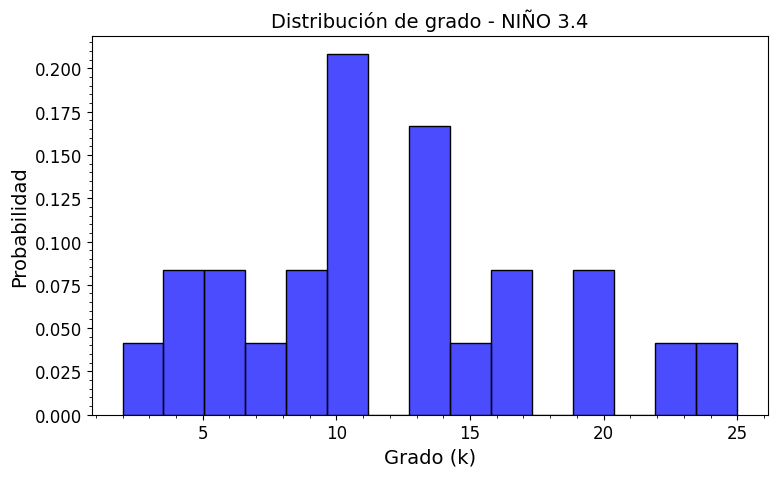

Distribución de grado - NIÑO 3.4
  Estadísticas: media=11.9167, varianza=35.6449, asimetría=0.4255, curtosis=-0.4873
  Segundo momento ⟨k²⟩ = 176.1667
  Exponente γ = 2.4341 ± 0.3290 (xmin = 7.0)
  p-valor (vs. exponencial) = 0.0000
  Grado mínimo: 2, máximo: 25



/home/santiago/Escritorio/UNIVERSIDAD/TRABAJO_DE_GRADO/entorno_trabajo_grado/lib/python3.12/site-packages/powerlaw/distributions.py:183: UserWarning: discrete=False but data exclusively contains integer values. Consider using discrete=True.
  warnings.warn('discrete=False but data exclusively contains integer values. Consider using discrete=True.')


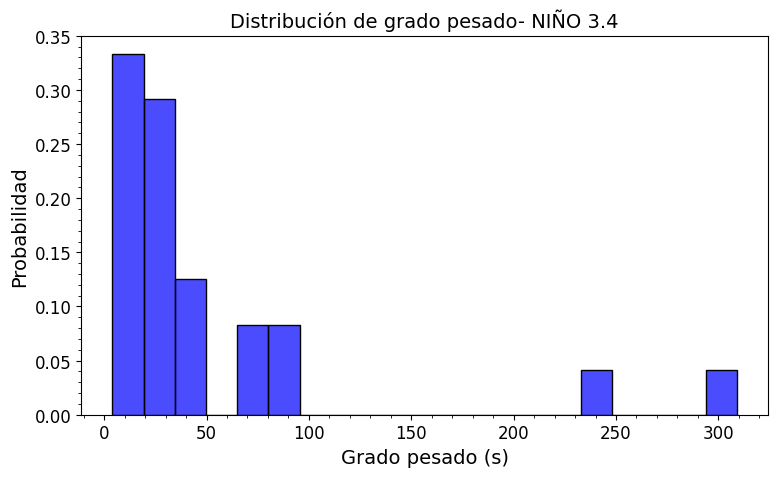

Distribución de grado pesado - NIÑO 3.4
  Estadísticas: media=51.3333, varianza=5402.8406, asimetría=2.5761, curtosis=5.8326
  Segundo momento ⟨s²⟩ = 7812.8333
  Exponente γ = 2.3347 ± 0.3337 (xmin = 24.0)
  p-valor (vs. exponencial) = 0.0785
  Fuerza mínima: 4.00, máxima: 309.00



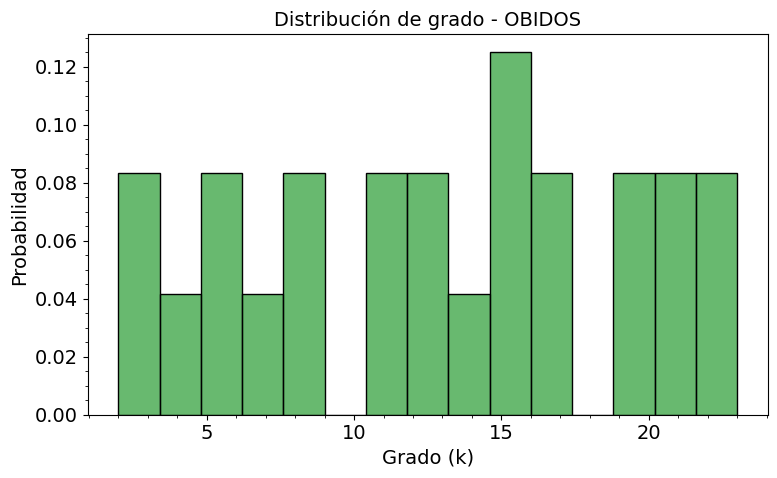

Distribución de grado - OBIDOS
  Estadísticas: media=12.8333, varianza=40.3188, asimetría=-0.0587, curtosis=-1.1290
  Segundo momento ⟨k²⟩ = 203.3333
  Exponente γ = 2.4719 ± 0.3469 (xmin = 8.0)
  p-valor (vs. exponencial) = 0.0001
  Grado mínimo: 2, máximo: 23



/home/santiago/Escritorio/UNIVERSIDAD/TRABAJO_DE_GRADO/entorno_trabajo_grado/lib/python3.12/site-packages/powerlaw/distributions.py:183: UserWarning: discrete=False but data exclusively contains integer values. Consider using discrete=True.
  warnings.warn('discrete=False but data exclusively contains integer values. Consider using discrete=True.')


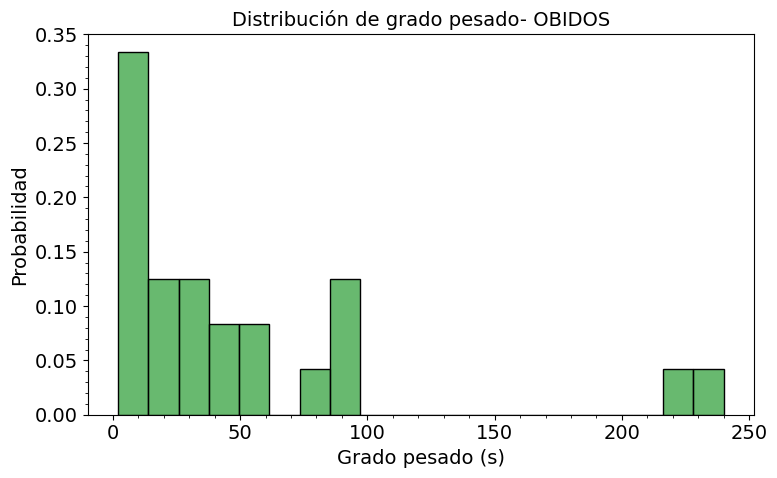

Distribución de grado pesado - OBIDOS
  Estadísticas: media=51.3333, varianza=3857.7971, asimetría=1.9953, curtosis=3.3452
  Segundo momento ⟨s²⟩ = 6332.1667
  Exponente γ = 2.5990 ± 0.5057 (xmin = 46.0)
  p-valor (vs. exponencial) = 0.7531
  Fuerza mínima: 2.00, máxima: 240.00



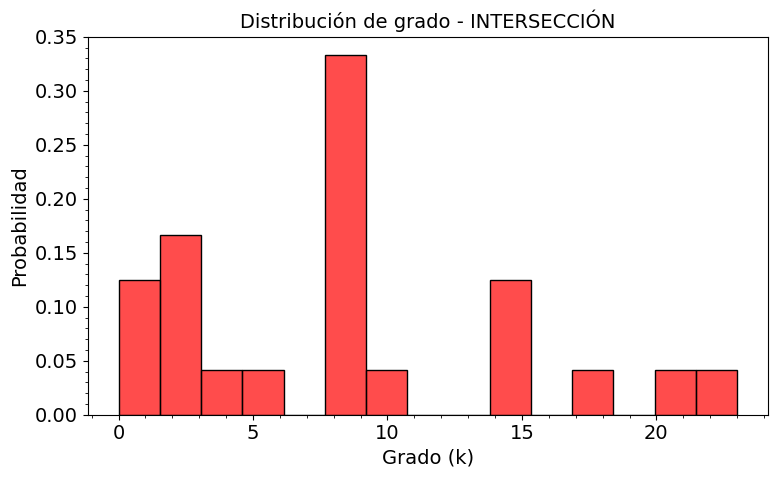

Distribución de grado - INTERSECCIÓN
  Estadísticas: media=8.5833, varianza=41.5580, asimetría=0.6453, curtosis=-0.3979
  Segundo momento ⟨k²⟩ = 113.5000
  Exponente γ = 2.4499 ± 0.3625 (xmin = 6.0)
  p-valor (vs. exponencial) = 0.0021
  Grado mínimo: 0, máximo: 23



/home/santiago/Escritorio/UNIVERSIDAD/TRABAJO_DE_GRADO/entorno_trabajo_grado/lib/python3.12/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution exponential; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')


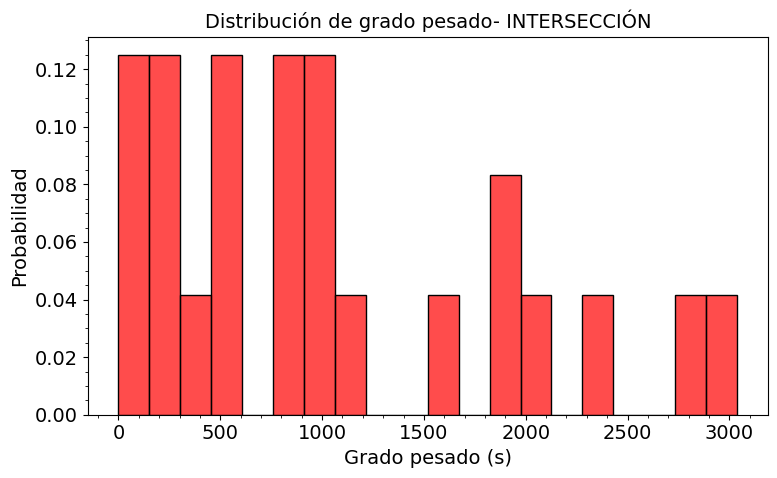

Distribución de grado pesado - INTERSECCIÓN
  Estadísticas: media=1053.5293, varianza=769796.0084, asimetría=0.8007, curtosis=-0.3645
  Segundo momento ⟨s²⟩ = 1847645.0582
  Exponente γ = 2.8031 ± 0.4819 (xmin = 828.5714285714286)
  p-valor (vs. exponencial) = 0.6610
  Fuerza mínima: 0.00, máxima: 3037.92



In [34]:
# Suponiendo que tienes G, G1 y GC definidos
plot_degree_distribution(G, "NIÑO 3.4", color='blue', bins=15, loglog=False)
plot_degree_distribution_pesada(G, "NIÑO 3.4", color='blue', bins=20, loglog=False)

plot_degree_distribution(G1, "OBIDOS", color='#289c32', bins=15, loglog=False)
plot_degree_distribution_pesada(G1, "OBIDOS", color='#289c32', bins=20, loglog=False)

plot_degree_distribution(GC, "INTERSECCIÓN", color='red', bins=15, loglog=False)
plot_degree_distribution_pesada(GC, "INTERSECCIÓN", color='red', bins=20, loglog=False)

In [35]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

def correlacion_pearson(x, y, nombre_x='Serie X', nombre_y='Serie Y'):
    """
    Calcula la correlación de Pearson entre dos series y genera una gráfica de dispersión.

    Parámetros:
    x, y : listas o arrays unidimensionales de la misma longitud.
    nombre_x, nombre_y : etiquetas para los ejes.

    Retorna:
    r : coeficiente de correlación de Pearson.
    p : valor p asociado.
    """
    x = np.array(x)
    y = np.array(y)
    if len(x) != len(y):
        raise ValueError("Las series deben tener la misma longitud")

    # Calcular correlación de Pearson
    r, p = stats.pearsonr(x, y)

    # Ajuste lineal para la recta de regresión
    slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)

    # Crear gráfica
    plt.figure(figsize=(8, 6))
    plt.scatter(x, y, alpha=0.6, edgecolors='k', linewidth=0.5)
    # Recta de regresión
    x_line = np.linspace(x.min(), x.max(), 100)
    y_line = slope * x_line + intercept
    plt.plot(x_line, y_line, 'r-', label=f'Regresión lineal (r={r:.3f})')
    plt.xlabel(nombre_x)
    plt.ylabel(nombre_y)
    #plt.title(f'Correlación de Pearson: r={r:.3f}, p={p:.3e}')
    #plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.rcParams.update({
    'font.size': 14,
    'axes.titlesize': 14,
    'axes.labelsize': 14,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 14
})
    plt.show()

    print(f"Coeficiente de correlación de Pearson: r = {r:.4f}")
    print(f"Valor p: {p:.4e}")
    return r, p

##PEARSON

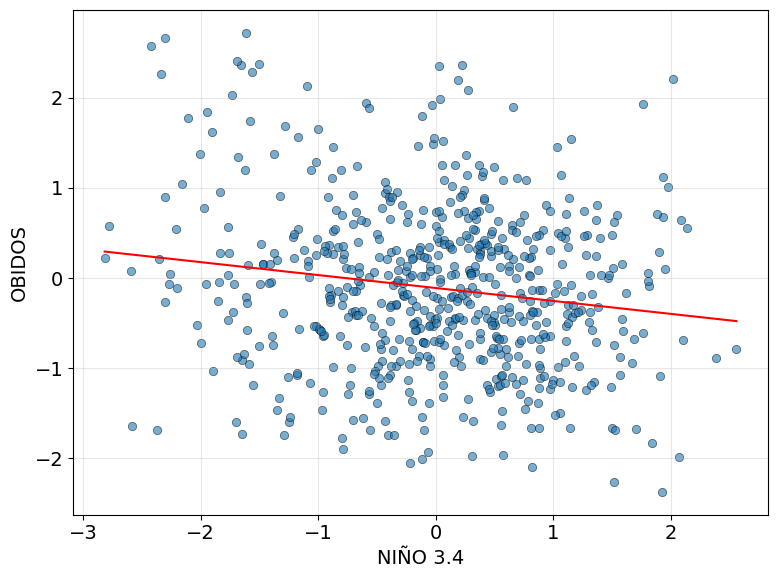

Coeficiente de correlación de Pearson: r = -0.1576
Valor p: 7.8302e-05


In [36]:
# Suponiendo que tienes las series x (NIÑO) y x1 (CALAMAR) definidas
r, p = correlacion_pearson(x1, x, nombre_y='OBIDOS', nombre_x='NIÑO 3.4')

##BOOTSTRAP

In [37]:
porcentaje_para_comparar=promedio
print(porcentaje_para_comparar)

21.948526069553214


Resultados del bootstrap clásico sobre x1 (1000 remuestras):
Media: 29.66
Mediana: 29.69
Desviación estándar: 1.68
Intervalo de confianza 95%: (26.38, 32.80)
Distancia del observado respecto a la media bootstrap: -4.58 desviaciones estándar


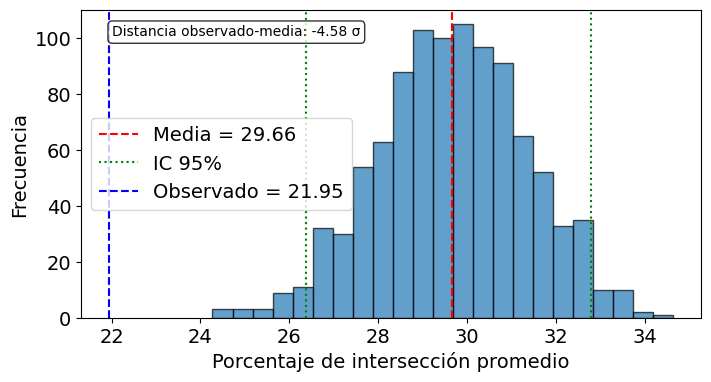

In [38]:
import numpy as np
import matplotlib.pyplot as plt

# Parámetros
w_opt = 4
n_bootstrap = 1000          # número de remuestras
np.random.seed(42)          # para reproducibilidad

# Asegurarse de que A (matriz del niño) está calculada a partir de x
# Si no lo está, calcúlala aquí:
# nodos_x = crear_ind(x, w_opt)
# G_x, _, _ = crear_grafo(nodos_x, w_opt)
# A = nx.to_numpy_array(G_x, dtype=int)

# Lista para almacenar los resultados
porcents_boot = []

for i in range(n_bootstrap):
    # 1. Remuestrear x1 con reemplazo (bootstrap clásico)
    indices_boot = np.random.choice(len(x1), size=len(x1), replace=True)
    x1_boot = [x1[i] for i in indices_boot]   # si x1 es lista
    # Si x1 es array de numpy: x1_boot = x1[indices_boot]

    # 2. Obtener índices de patrones ordinales de la remuestra
    nodos_boot = crear_ind(x1_boot, w_opt)

    # 3. Construir grafo y matriz de adyacencia
    G_boot, _, _ = crear_grafo(nodos_boot, w_opt)
    A_boot = nx.to_numpy_array(G_boot, dtype=int)

    # 4. Calcular la métrica de similitud con A (la red del niño)
    with np.errstate(divide='ignore', invalid='ignore'):
        C = np.divide(A_boot, A, out=np.zeros_like(A, dtype=float), where=A != 0) * 100
    C_clean = np.where(np.isinf(C), 0, C)
    upper = np.triu(C_clean, k=1)          # triángulo superior sin diagonal
    promedio = np.mean(upper)               # promedio de todas las celdas (incluye ceros)
    # Si prefieres solo celdas con valor positivo:
    # promedio = np.mean(upper[upper > 0]) if np.any(upper > 0) else 0

    porcents_boot.append(promedio)

porcents_boot = np.array(porcents_boot)

# Estadísticos
media_boot = np.mean(porcents_boot)
mediana_boot = np.median(porcents_boot)
desv_boot = np.std(porcents_boot, ddof=1)
ic_inf = np.percentile(porcents_boot, 2.5)
ic_sup = np.percentile(porcents_boot, 97.5)
# Distancia del valor observado respecto a la media bootstrap (en desviaciones estándar)
distancia_sd = (porcentaje_para_comparar - media_boot) / desv_boot


print(f"Resultados del bootstrap clásico sobre x1 ({n_bootstrap} remuestras):")
print(f"Media: {media_boot:.2f}")
print(f"Mediana: {mediana_boot:.2f}")
print(f"Desviación estándar: {desv_boot:.2f}")
print(f"Intervalo de confianza 95%: ({ic_inf:.2f}, {ic_sup:.2f})")
print(f"Distancia del observado respecto a la media bootstrap: {distancia_sd:.2f} desviaciones estándar")

# Histograma
plt.figure(figsize=(8,4))
plt.hist(porcents_boot, bins='auto', alpha=0.7, edgecolor='black')
plt.axvline(media_boot, color='red', linestyle='--', label=f'Media = {media_boot:.2f}')
plt.axvline(ic_inf, color='green', linestyle=':', label='IC 95%')
plt.axvline(ic_sup, color='green', linestyle=':')
plt.axvline(porcentaje_para_comparar, color='blue', linestyle='--', label=f'Observado = {porcentaje_para_comparar:.2f}')
#plt.title('Distribución bootstrap de la similitud (A vs remuestras de x1)')
# Agregar anotación con la distancia en SD (opción con recuadro)
plt.text(0.05, 0.95, f'Distancia observado-media: {distancia_sd:.2f} σ',
         transform=plt.gca().transAxes, fontsize=10,
         verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
plt.xlabel('Porcentaje de intersección promedio')
plt.ylabel('Frecuencia')
plt.legend()
plt.show()